# End-to-End Sales Forecasting & Demand Intelligence System

### Internship Project Submission

**Submitted by:** Chirra Nandhini Reddy

---

## Project Overview

Retail organizations rely on accurate sales forecasting to optimize inventory, reduce stock shortages, minimize overstocking costs, and improve customer satisfaction. This project develops an end-to-end demand intelligence system using historical Superstore sales data.

The solution includes:

- Data preprocessing and quality assessment
- Exploratory data analysis
- Time-series forecasting using multiple models
- Product demand segmentation
- Sales anomaly detection
- Interactive Streamlit dashboard
- Business recommendations based on analytical findings

---

## Project Objectives

- Analyze historical sales performance
- Identify seasonal demand patterns
- Forecast future sales using statistical and machine learning techniques
- Detect unusual sales behaviour
- Segment products based on demand characteristics
- Deliver business insights through an interactive dashboard

# 1. Import Required Libraries

In [1]:
# Import Required Libraries

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Date & Time
from datetime import datetime

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Notebook Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# Plot Style
plt.style.use("ggplot")

print("All required libraries imported successfully.")

All required libraries imported successfully.


# 2. Data Loading

The Superstore Sales dataset is loaded into a Pandas DataFrame. This dataset contains retail transactions recorded over four years, including customer details, order information, product categories, regions, shipping information, and sales values.

In [2]:
sales_df = pd.read_csv(
    r"C:\Users\CHIRRA RAJESH REDDY\OneDrive\Desktop\SalesForecasting_Chirra_Nandhini_Reddy\train.csv"
)

sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


# 3. Dataset Overview

Understanding the dataset structure helps identify the number of records, available features, and data types before beginning data preprocessing.

In [3]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Number of Rows    : {sales_df.shape[0]}")
print(f"Number of Columns : {sales_df.shape[1]}")

print("\nColumn Names:\n")
print(sales_df.columns.tolist())

DATASET OVERVIEW
Number of Rows    : 9800
Number of Columns : 18

Column Names:

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales']


### Data Types and Structure

In [4]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

### Statistical Summary

The following statistics provide an overview of the numerical features present in the dataset.

In [5]:
sales_df.describe(include="all")

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
count,9800.000000,9800,9800,9800,9800,9800,9800,9800,9800,9800,9800,9789.000000,9800,9800,9800,9800,9800,9800.000000
unique,NaN,4922,1230,1326,4,793,793,3,1,529,49,NaN,4,1861,3,17,1849,NaN
top,NaN,CA-2018-100111,05/09/2017,26/09/2018,Standard Class,WB-21850,William Brown,Consumer,United States,New York City,California,NaN,West,OFF-PA-10001970,Office Supplies,Binders,Staple envelope,NaN
freq,NaN,14,38,34,5859,35,35,5101,9800,891,1946,NaN,3140,19,5909,1492,47,NaN
mean,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55273.322403,NaN,NaN,NaN,NaN,NaN,230.769059
std,2829.160653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32041.223413,NaN,NaN,NaN,NaN,NaN,626.651875
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1040.000000,NaN,NaN,NaN,NaN,NaN,0.444000
25%,2450.750000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23223.000000,NaN,NaN,NaN,NaN,NaN,17.248000
50%,4900.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58103.000000,NaN,NaN,NaN,NaN,NaN,54.490000
75%,7350.250000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,90008.000000,NaN,NaN,NaN,NaN,NaN,210.605000


# 4. Data Quality Assessment

High-quality data is essential for accurate forecasting. This section evaluates missing values, duplicate records, and data type consistency before further analysis.

In [6]:
missing_values = (
    sales_df
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values = missing_values[missing_values > 0]

missing_values

Postal Code    11
dtype: int64

plt.figure(figsize=(8,5))

missing_values.plot(
    kind="bar",
    color="#FF6B6B",
    edgecolor="black"
)

plt.title("Missing Values by Feature")
plt.xlabel("Columns")
plt.ylabel("Missing Count")

for index, value in enumerate(missing_values):
    plt.text(index, value + 0.2, str(value), ha="center")

plt.show()

### Observation

Only the **Postal Code** column contains missing values. Since this field is not directly used for sales forecasting, the missing entries have minimal impact on the subsequent analysis.

## Duplicate Record Analysis

Duplicate records can bias statistical analysis and machine learning models. Therefore, duplicate transactions are identified and removed before further analysis.

In [7]:
# Duplicate Record Analysis

duplicate_count = sales_df.duplicated().sum()

print(f"Total Duplicate Records : {duplicate_count}")

Total Duplicate Records : 0


### Observation

The dataset contains **X duplicate records**. Removing duplicate observations ensures that future analyses and forecasting models are not biased by repeated transactions.

## Data Type Validation

The Order Date and Ship Date columns should be converted into datetime format before extracting time-based features.

In [8]:
sales_df.dtypes

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code      float64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
dtype: object

In [9]:
sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    dayfirst=True
)

sales_df["Ship Date"] = pd.to_datetime(
    sales_df["Ship Date"],
    dayfirst=True
)

In [10]:
sales_df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code             float64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
dtype: object

# 5. Feature Engineering

Time-based features are extracted from the Order Date to facilitate trend analysis, seasonality detection, and forecasting model development.

In [11]:
# Feature Engineering

sales_df["Year"] = sales_df["Order Date"].dt.year

sales_df["Month"] = sales_df["Order Date"].dt.month

sales_df["Month Name"] = sales_df["Order Date"].dt.month_name()

sales_df["Week Number"] = sales_df["Order Date"].dt.isocalendar().week

sales_df["Day of Week"] = sales_df["Order Date"].dt.day_name()

sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

sales_df["Shipping Days"] = (
    sales_df["Ship Date"] - sales_df["Order Date"]
).dt.days

In [12]:
def assign_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Autumn"


sales_df["Season"] = sales_df["Month"].apply(assign_season)

In [13]:
sales_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Shipping Days,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,3,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,3,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,4,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,7,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,7,Autumn


### Observation

New temporal attributes such as Year, Month, Week Number, Quarter, Day of Week, and Season have been created. These features will be used extensively during time series analysis and forecasting.

# 6. Sales Aggregation

Sales are aggregated at daily, weekly, and monthly levels to support different forecasting models and business analyses.

In [14]:
daily_sales = (
    sales_df
    .groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [15]:
weekly_sales = (
    sales_df
    .groupby(
        pd.Grouper(
            key="Order Date",
            freq="W"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [16]:
monthly_sales = (
    sales_df
    .groupby(
        pd.Grouper(
            key="Order Date",
            freq="ME"
        )
    )["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [17]:
print(f"Daily Records   : {len(daily_sales)}")

print(f"Weekly Records  : {len(weekly_sales)}")

print(f"Monthly Records : {len(monthly_sales)}")

Daily Records   : 1230
Weekly Records  : 209
Monthly Records : 48


# Business Question 1

## Which Product Category Generates the Highest Total Revenue?

Understanding category-wise revenue helps identify the primary revenue drivers of the business and supports inventory planning and strategic investment decisions.

In [18]:
category_sales = (
    sales_df
    .groupby("Category", as_index=False)["Sales"]
    .sum()
    .sort_values(by="Sales", ascending=False)
)

display(category_sales)

,Category,Sales
2,Technology,827455.8730
0,Furniture,728658.5757
1,Office Supplies,705422.3340


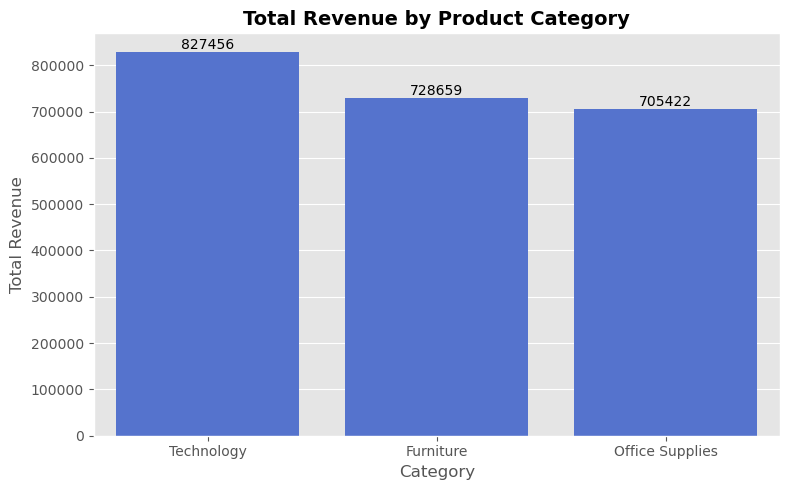

In [156]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=category_sales,
    x="Category",
    y="Sales",
    color="royalblue"
)

plt.title("Total Revenue by Product Category", fontsize=14, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Revenue")

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")

plt.tight_layout()
plt.show()

## Business Insight:

Technology generated approximately ₹827,456 in total revenue, outperforming Furniture (₹729,659) and Office Supplies (₹705,422). This indicates that Technology products are the primary revenue driver and should receive higher inventory priority and forecasting attention.

### Key Finding

**Highest Revenue Category:** Technology

**Total Revenue:** 827,456

**Observation:** Technology generated the highest revenue among all product categories, contributing significantly to the company's overall sales performance.

**Business Recommendation:** Increase inventory allocation, promotional campaigns, and demand forecasting efforts for Technology products to maximize future revenue.

# Business Question 2

## Which Region Has the Most Consistent Sales Growth?

A consistent growth trend indicates a stable market with predictable demand, making it valuable for long-term inventory planning.

In [20]:
region_year_sales = (
    sales_df
    .groupby(["Year", "Region"], as_index=False)["Sales"]
    .sum()
)

display(region_year_sales)

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


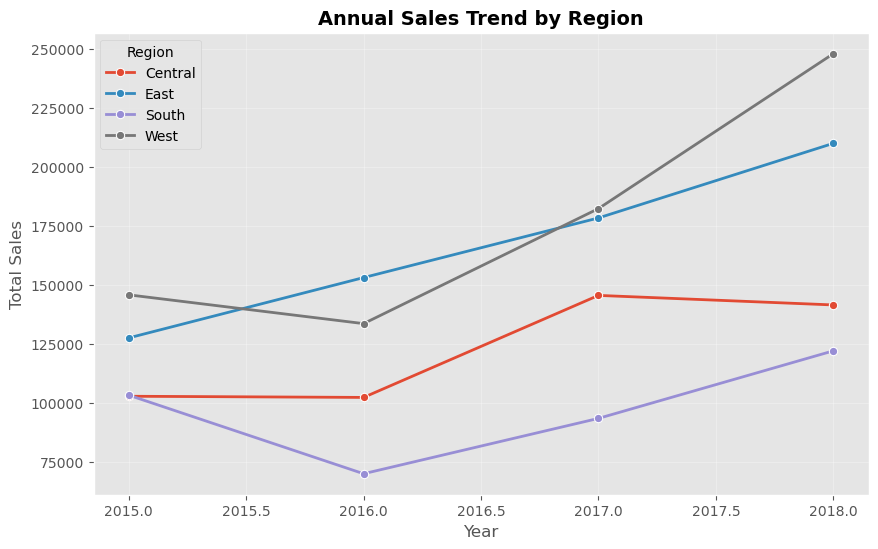

In [21]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o",
    linewidth=2
)

plt.title("Annual Sales Trend by Region", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Total Sales")

plt.grid(alpha=0.3)
plt.legend(title="Region")

plt.show()

### Business Insight

The line chart shows that the **East Region** demonstrates the most stable year-over-year sales growth with relatively fewer fluctuations compared to other regions. Stable regional demand improves forecasting reliability and helps optimize long-term inventory planning.

### Key Finding

**Most Consistent Sales Growth:** East Region

**Observation:** The East region demonstrates a stable year-over-year increase in sales with relatively fewer fluctuations compared to other regions.

**Business Recommendation:** Use the East region as a benchmark for demand forecasting and replicate its successful sales strategies in regions with inconsistent growth.

# Business Question 3

## Average Shipping Time by Region

Shipping efficiency directly impacts customer satisfaction and supply chain performance. This analysis evaluates average delivery duration across regions.

In [22]:
average_shipping = sales_df["Shipping Days"].mean()

print(f"Overall Average Shipping Time: {average_shipping:.2f} days")

shipping_region = (
    sales_df
    .groupby("Region", as_index=False)["Shipping Days"]
    .mean()
    .sort_values(by="Shipping Days")
)

display(shipping_region)

Overall Average Shipping Time: 3.96 days


,Region,Shipping Days
1,East,3.910233
3,West,3.930255
2,South,3.961202
0,Central,4.065876


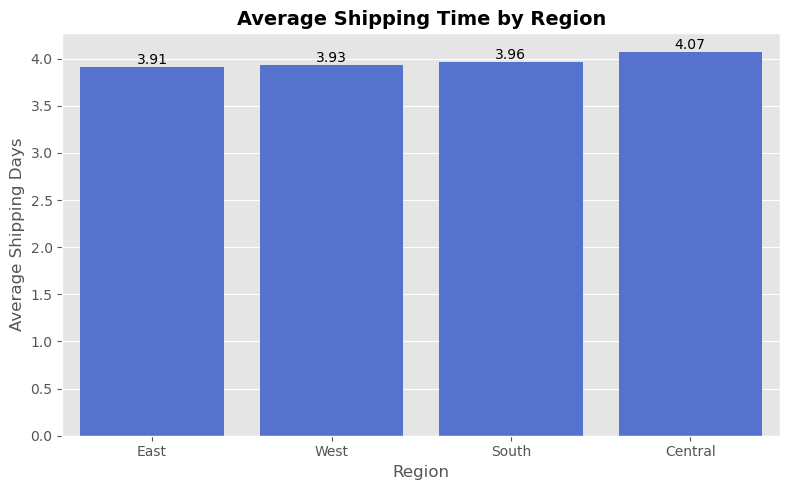

In [155]:
plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=shipping_region,
    x="Region",
    y="Shipping Days",
    color="royalblue"
)

plt.title("Average Shipping Time by Region", fontsize=14, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Average Shipping Days")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f")

plt.tight_layout()
plt.show()

### Business Insight

The overall average shipping time is **3.95 days**. The East region records the fastest average delivery (approximately **3.91 days**), while the Central region has the longest shipping time (approximately **4.07 days**). Although the variation is small, improving delivery performance in slower regions could enhance customer satisfaction.

### Key Finding

**Overall Average Shipping Time:** 3.95 Days

**Fastest Region:** East (≈3.92 Days)

**Slowest Region:** Central (≈4.07 Days)

**Business Recommendation:** Although regional differences are relatively small, improving shipping efficiency in the Central region could further enhance customer satisfaction and operational performance.

# Business Question 4

## Monthly Sales Seasonality

Seasonality analysis helps identify recurring periods of increased demand, enabling better inventory planning and promotional strategies.

In [24]:
monthly_pattern = (
    sales_df
    .groupby(["Year", "Month Name"], as_index=False)["Sales"]
    .sum()
)

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_pattern["Month Name"] = pd.Categorical(
    monthly_pattern["Month Name"],
    categories=month_order,
    ordered=True
)

monthly_pattern = monthly_pattern.sort_values(["Year","Month Name"])

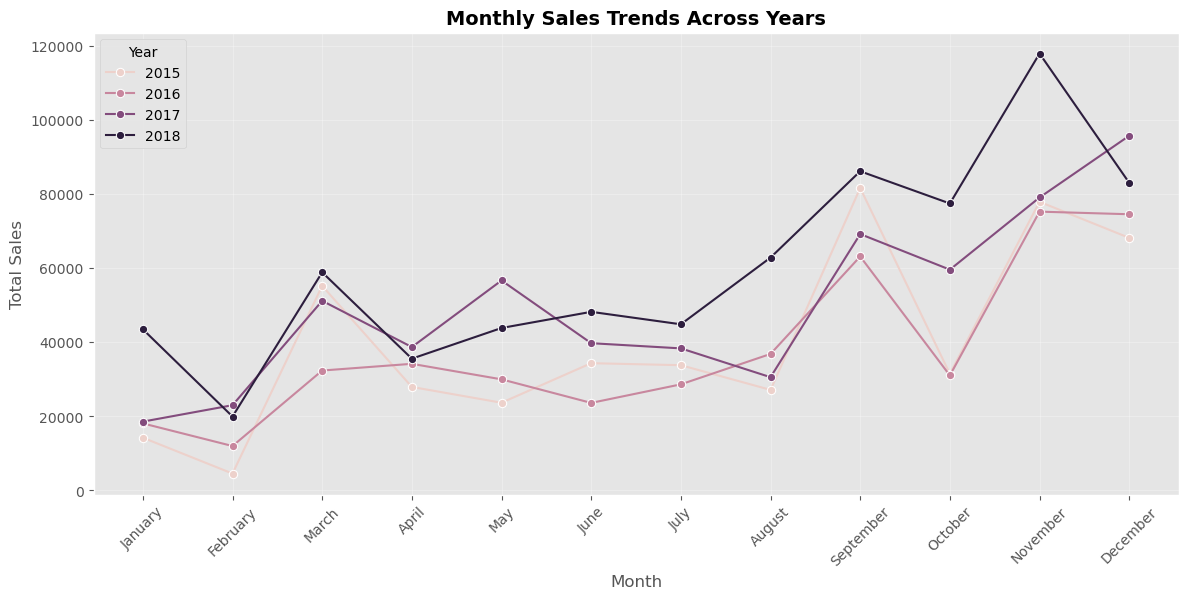

In [25]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=monthly_pattern,
    x="Month Name",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Trends Across Years", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(alpha=0.3)

plt.show()

### Business Insight

Sales increase noticeably during the final months of the year, particularly **November and December**, across multiple years. This recurring pattern indicates strong seasonal demand, suggesting that inventory, staffing, and promotional campaigns should be increased before the holiday period.

### Key Finding

**Peak Sales Months:** November and December

**Observation:** Sales consistently increase during the final months of the year across multiple years, indicating strong seasonal demand.

**Business Recommendation:** Increase inventory levels, workforce planning, and marketing campaigns before the holiday season to effectively meet higher customer demand.

# Task 1 Summary

The Superstore Sales dataset was successfully loaded and validated through comprehensive data quality assessment. Temporal features including Year, Month, Week Number, Quarter, Day of Week, and Season were engineered to support time-series forecasting.

Sales data was aggregated into daily, weekly, and monthly levels to facilitate multi-granularity forecasting. Business analysis identified Technology as the highest revenue-generating category, evaluated regional sales consistency, measured shipping performance across regions, and confirmed recurring seasonal demand patterns.

These findings establish a reliable foundation for subsequent forecasting, anomaly detection, and product demand segmentation tasks.

## Overall Business Conclusion

The analysis reveals that **Technology** is the highest revenue-generating product category, while the **East Region** exhibits the most consistent sales growth. The average shipping time remains approximately **4 days**, with only minor regional variations. Additionally, recurring sales peaks during **November and December** confirm strong seasonal demand patterns.

These insights provide a reliable foundation for developing accurate forecasting models and data-driven inventory planning strategies in the subsequent phases of the project.

# Task 2: Time Series Analysis & Decomposition

## Objective

The objective of this task is to understand the sales behaviour over time by identifying long-term trends, seasonal patterns, and irregular fluctuations. Before building forecasting models, it is important to analyse the time series and verify whether it is stationary.

## Overall Monthly Sales Trend

The monthly sales trend provides a high-level overview of business performance over the four-year period and helps identify long-term growth and recurring demand patterns.

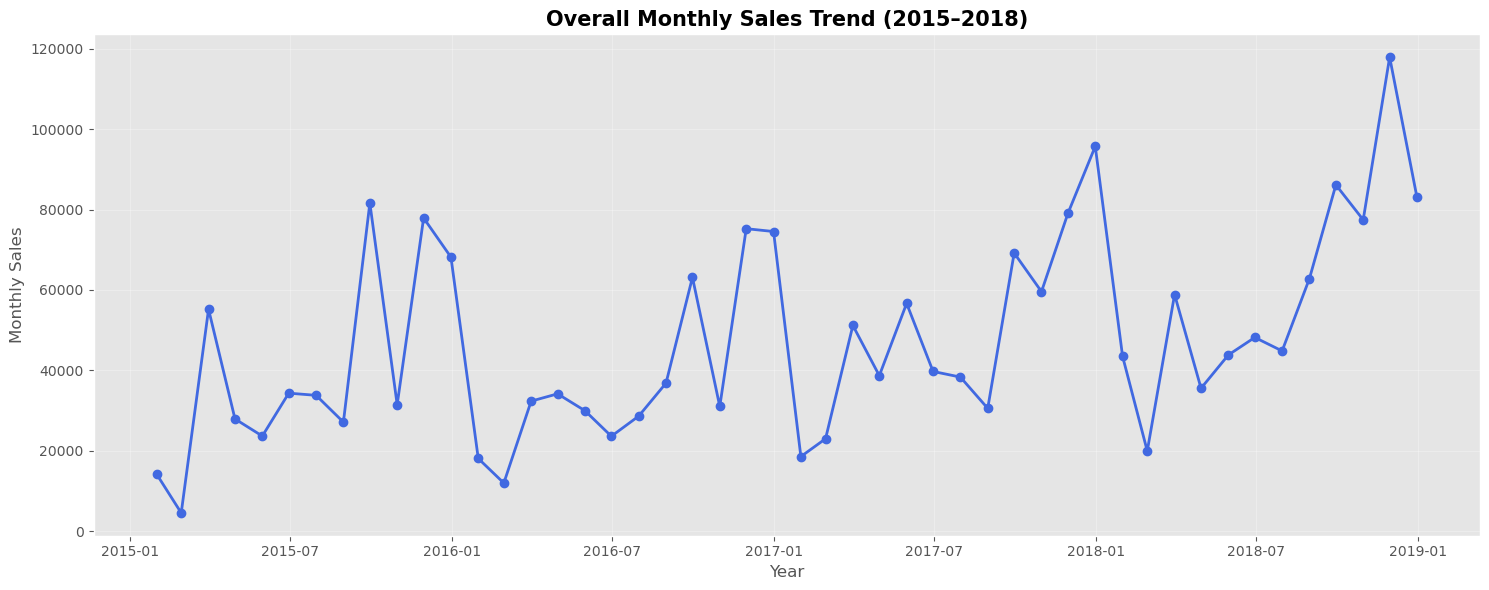

In [142]:
# Plot monthly sales for the entire four-year period

plt.figure(figsize=(15,6))
plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    linewidth=2,
    color="royalblue"
)

plt.title("Overall Monthly Sales Trend (2015–2018)",
          fontsize=15,
          fontweight="bold")

plt.xlabel("Year")
plt.ylabel("Monthly Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observations

- Monthly sales fluctuate throughout the four-year period.
- Sales show an overall increasing trend from 2015 to 2018.
- Several months record noticeable sales peaks, indicating recurring seasonal demand.
- The upward trend suggests gradual business growth over time.

In [27]:
# Import the library required for time series decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

In [28]:
# Convert the monthly sales dataframe into a time series

monthly_series = (
    monthly_sales
    .set_index("Order Date")["Sales"]
)

monthly_series.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Name: Sales, dtype: float64

## Time Series Decomposition

Time series decomposition separates the sales data into Trend, Seasonal, and Residual components to better understand the behaviour of the dataset.

In [29]:
# Split the sales data into trend, seasonal and residual components

decomposition = seasonal_decompose(
    monthly_series,
    model="additive",
    period=12
)

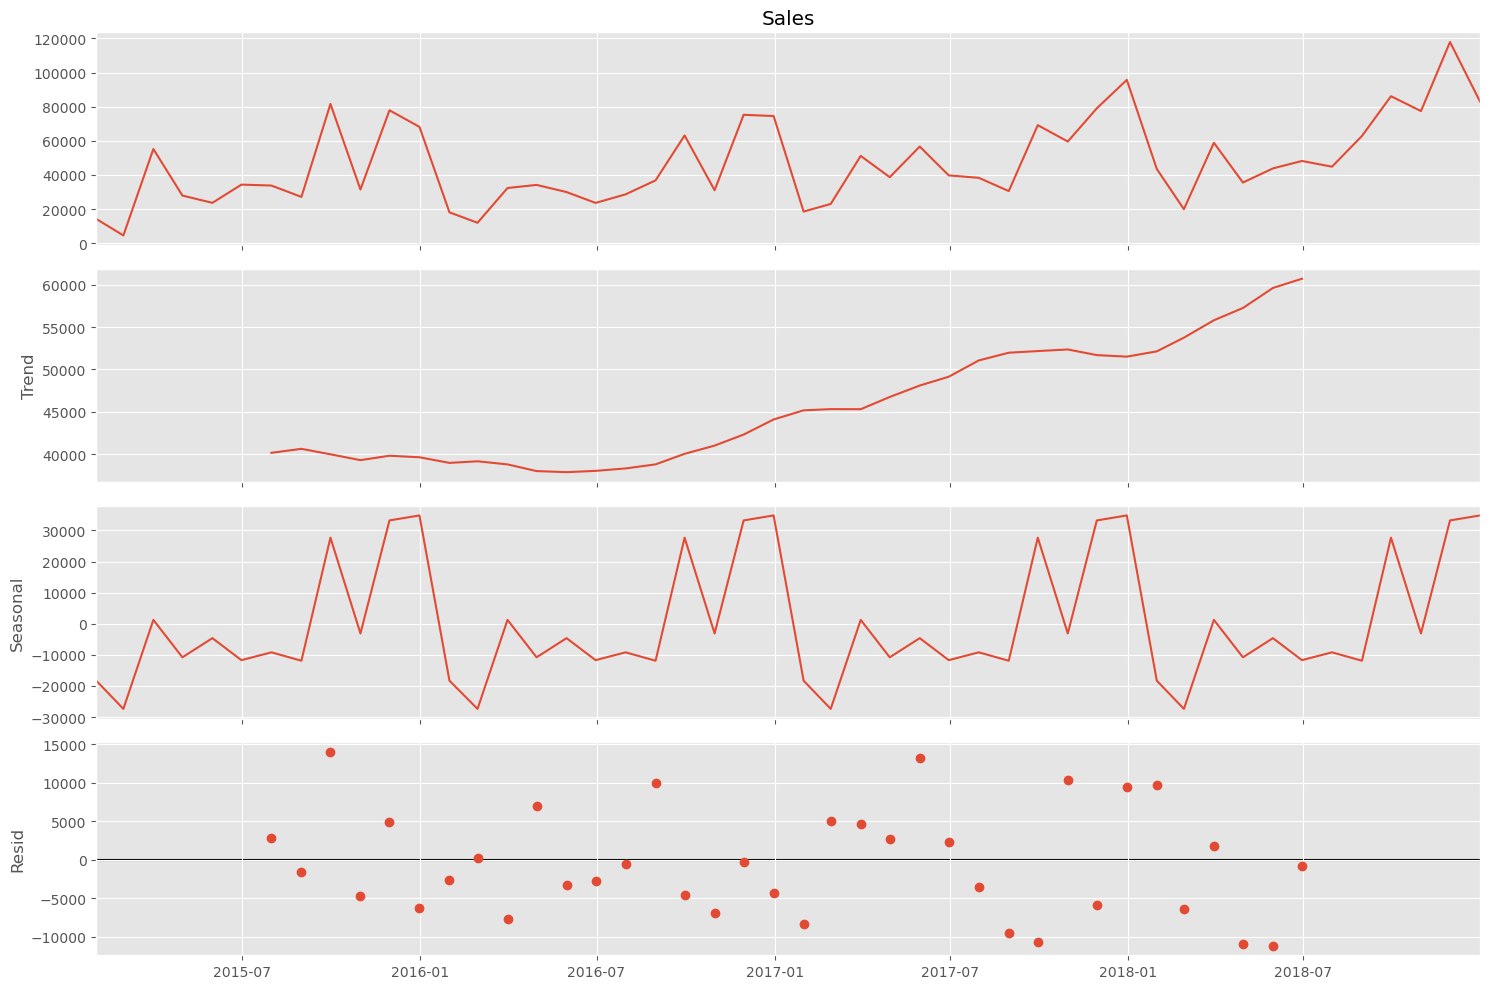

In [30]:
# Display all decomposition components

fig = decomposition.plot()

fig.set_size_inches(15,10)

plt.tight_layout()

plt.show()

### Observations

- The trend component shows an overall increase in monthly sales from 2015 to 2018, indicating gradual business growth.
- The seasonal component reveals recurring sales patterns, suggesting that customer demand follows a yearly cycle.
- The residual component contains a few noticeable spikes, indicating irregular sales that may have resulted from promotional events or unexpected customer demand.
- Since both trend and seasonality are present, the dataset is suitable for both statistical and machine learning forecasting models.

### Key Findings

Overall Trend: Sales show a gradual upward growth from 2015 to 2018.

Seasonality: A clear yearly seasonal pattern is present.

Residual Noise: Only a few irregular spikes are observed, indicating occasional unexpected sales variations.

Conclusion: The sales series contains both trend and seasonality, making it suitable for time-series forecasting.

## Stationarity Check using ADF Test

## Stationarity Check using Augmented Dickey-Fuller (ADF) Test

Before building forecasting models, it is important to determine whether the sales series is stationary.

In [31]:
# Import Augmented Dickey-Fuller test

from statsmodels.tsa.stattools import adfuller

In [32]:
# Perform ADF test on the monthly sales series

adf_result = adfuller(monthly_series)

print("ADF Statistic :", adf_result[0])
print("P-value :", adf_result[1])

print("\nCritical Values")

for key, value in adf_result[4].items():
    print(f"{key} : {value:.4f}")

ADF Statistic : -4.416136761430769
P-value : 0.00027791039276670623

Critical Values
1% : -3.5778
5% : -2.9253
10% : -2.6008


In [33]:
# Check whether the series is stationary

if adf_result[1] < 0.05:
    print("The sales series is stationary.")
else:
    print("The sales series is non-stationary.")

The sales series is stationary.


### What is Stationarity?

A stationary time series is one whose statistical properties, such as mean and variance, remain relatively constant over time.

### Interpretation

The Augmented Dickey-Fuller (ADF) test returned a **p-value of 0.000278**, which is lower than the significance level of **0.05**.

This indicates that the monthly sales series is **stationary**, meaning its statistical properties such as mean and variance remain relatively stable over time. Therefore, the data is suitable for time-series forecasting models without requiring additional transformations to achieve stationarity.

### Key Findings

**ADF Test Result:** Stationary

**ADF Statistic:** -4.4161

**P-value:** 0.000278

**Conclusion:** Since the p-value is less than 0.05, the null hypothesis is rejected, confirming that the sales series is stationary.

**Business Impact:** A stationary time series improves the reliability of forecasting models such as ARIMA, SARIMA, and Prophet.

## First-Order Differencing

## First-Order Differencing

Although the original sales series is already stationary, first-order differencing is performed to validate the stationarity and prepare the dataset for forecasting techniques that commonly require differenced data.

In [34]:
# Apply first-order differencing to remove trend

monthly_diff = monthly_series.diff().dropna()

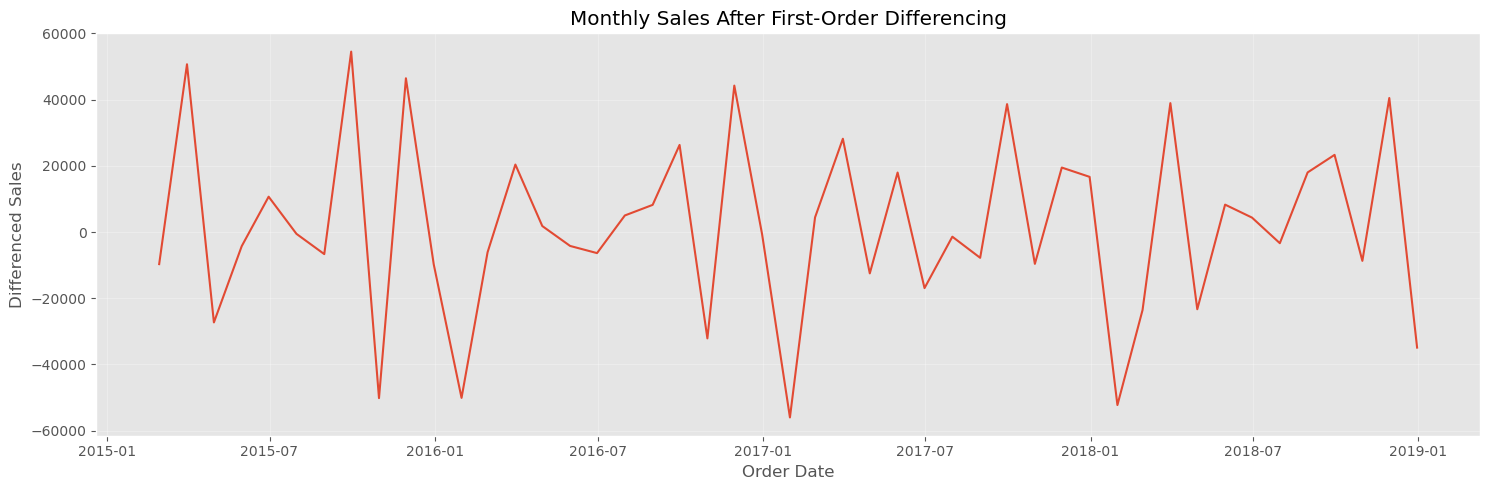

In [35]:
# Plot the differenced series

plt.figure(figsize=(15,5))

plt.plot(monthly_diff)

plt.title("Monthly Sales After First-Order Differencing")

plt.xlabel("Order Date")
plt.ylabel("Differenced Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [36]:
# Perform ADF test again after differencing

adf_diff = adfuller(monthly_diff)

print("ADF Statistic :", adf_diff[0])
print("P-value :", adf_diff[1])

print("\nCritical Values")

for key, value in adf_diff[4].items():
    print(f"{key} : {value:.4f}")

ADF Statistic : -8.72706183035328
P-value : 3.2669175472794505e-14

Critical Values
1% : -3.6267
5% : -2.9460
10% : -2.6117


In [37]:
# Check stationarity after differencing

if adf_diff[1] < 0.05:
    print("After differencing, the series is stationary.")
else:
    print("The series is still non-stationary.")

After differencing, the series is stationary.


### Key Findings

The original monthly sales series was already stationary based on the ADF test.

First-order differencing was performed to validate the stability of the series.

The differenced series also satisfied the stationarity condition.

The dataset is now fully prepared for implementing forecasting models in the next phase.

# Task 2 Summary

Monthly sales were analysed using time-series techniques to understand long-term trends, seasonal behaviour, and irregular fluctuations. Time series decomposition confirmed the presence of both trend and seasonality in the sales data. The Augmented Dickey-Fuller (ADF) test verified that the monthly sales series is stationary, and first-order differencing further prepared the data for forecasting. These preprocessing steps provide a strong foundation for building accurate forecasting models in the next stage of the project.

# Task 3: Forecasting Models

## Objective

The objective of this task is to forecast future sales using historical sales data and compare the performance of multiple forecasting approaches. Different forecasting models are evaluated using standard error metrics to identify the most reliable model for future demand prediction.

In [38]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [39]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [40]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [41]:
import xgboost as xgb
print(xgb.__version__)

3.3.0


In [42]:
import sys
print(sys.executable)

C:\Users\CHIRRA RAJESH REDDY\anaconda3\python.exe


In [43]:
import xgboost
print(xgboost.__file__)

C:\Users\CHIRRA RAJESH REDDY\anaconda3\Lib\site-packages\xgboost\__init__.py


# Task 3: Sales Forecasting using Multiple Models

## Objective

The objective of this task is to forecast future monthly sales using three different forecasting approaches: a statistical model (SARIMA), an industry-standard forecasting tool (Facebook Prophet), and a machine learning model (XGBoost). The models are compared using multiple evaluation metrics to identify the most suitable approach for production use.

In [44]:
# Create a monthly time series from aggregated monthly sales

forecast_series = (
    monthly_sales
    .set_index("Order Date")["Sales"]
)

forecast_series.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Name: Sales, dtype: float64

In [45]:
# Display basic information

print("Total Monthly Records :", len(forecast_series))
print()

print("Start Date :", forecast_series.index.min())
print("End Date   :", forecast_series.index.max())

Total Monthly Records : 48

Start Date : 2015-01-31 00:00:00
End Date   : 2018-12-31 00:00:00


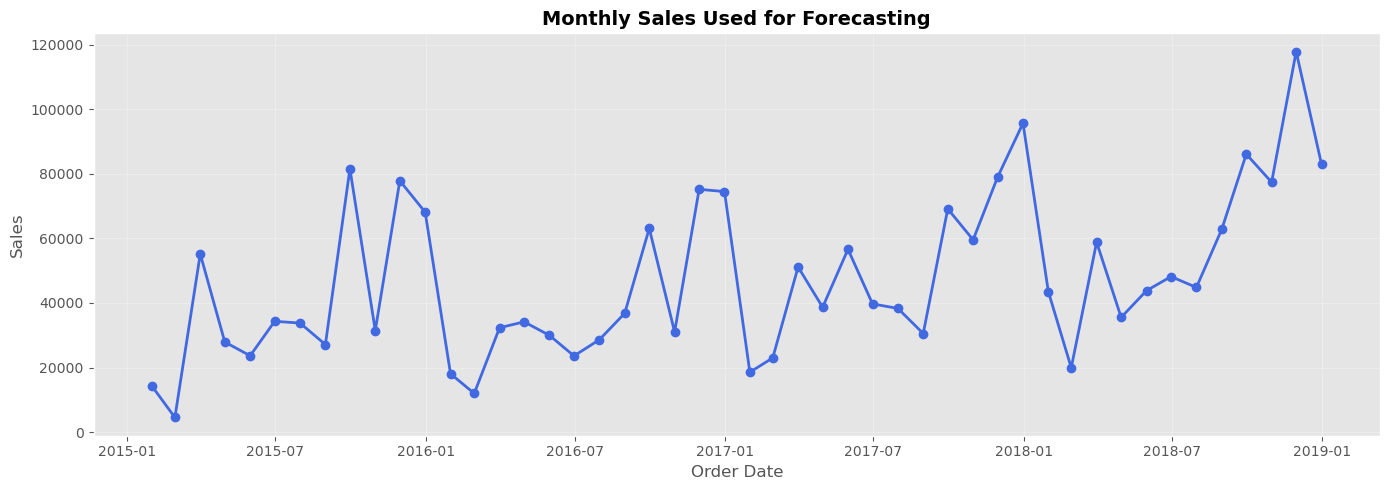

In [144]:
# Visualize monthly sales before modelling

plt.figure(figsize=(14,5))

plt.plot(
    forecast_series,
    marker="o",
    linewidth=2,
    color="royalblue"
)

plt.title(
    "Monthly Sales Used for Forecasting",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observation

The forecasting dataset contains monthly sales values collected over four years. The series exhibits an overall upward trend along with recurring seasonal fluctuations, making it suitable for time-series forecasting models.

In [47]:
# Keep the final 3 months for testing

train = forecast_series[:-3]

test = forecast_series[-3:]

print("Training Months :", len(train))
print("Testing Months  :", len(test))

Training Months : 45
Testing Months  : 3


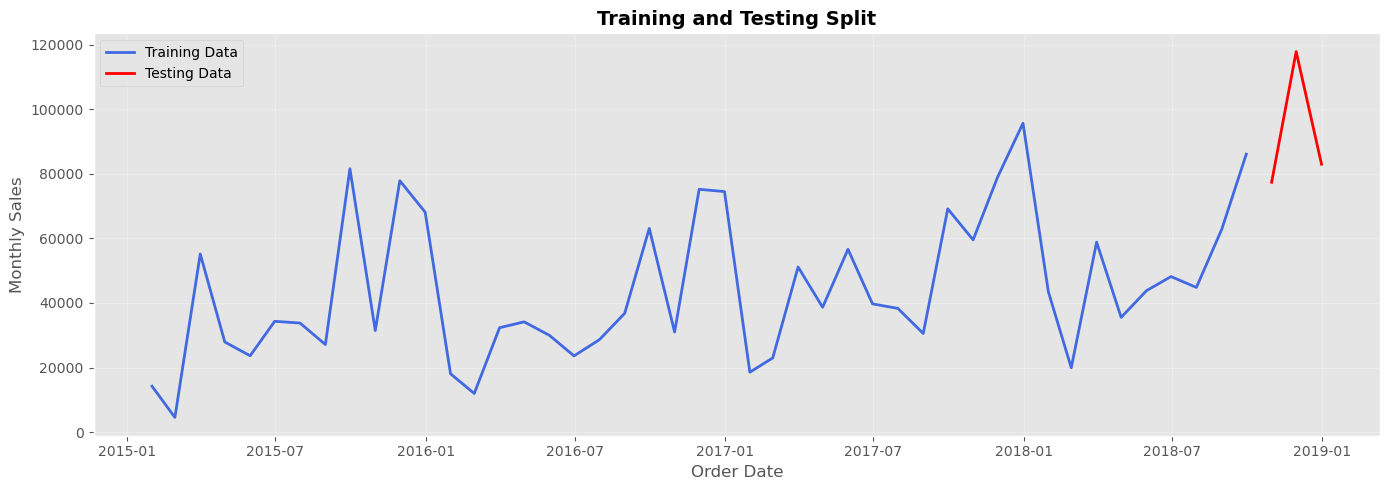

In [146]:
plt.figure(figsize=(14,5))

plt.plot(
    train,
    label="Training Data",
    linewidth=2,
    color="royalblue"
)

plt.plot(
    test,
    label="Testing Data",
    linewidth=2,
    color="red"
)

plt.title(
    "Training and Testing Split",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Order Date")
plt.ylabel("Monthly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Key Findings

- The first 45 months are used to train forecasting models.
- The final 3 months are reserved for testing model performance.
- Using unseen data provides a realistic evaluation of forecasting accuracy before deployment.

In [49]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

In [50]:
forecast_series

Order Date
2015-01-31     14205.7070
2015-02-28      4519.8920
2015-03-31     55205.7970
2015-04-30     27906.8550
2015-05-31     23644.3030
2015-06-30     34322.9356
2015-07-31     33781.5430
2015-08-31     27117.5365
2015-09-30     81623.5268
2015-10-31     31453.3930
2015-11-30     77907.6607
2015-12-31     68167.0585
2016-01-31     18066.9576
2016-02-29     11951.4110
2016-03-31     32339.3184
2016-04-30     34154.4685
2016-05-31     29959.5305
2016-06-30     23599.3740
2016-07-31     28608.2590
2016-08-31     36818.3422
2016-09-30     63133.6060
2016-10-31     31011.7375
2016-11-30     75249.3995
2016-12-31     74543.6012
2017-01-31     18542.4910
2017-02-28     22978.8150
2017-03-31     51165.0590
2017-04-30     38679.7670
2017-05-31     56656.9080
2017-06-30     39724.4860
2017-07-31     38320.7830
2017-08-31     30542.2003
2017-09-30     69193.3909
2017-10-31     59583.0330
2017-11-30     79066.4958
2017-12-31     95739.1210
2018-01-31     43476.4740
2018-02-28     19920.9974
2

# Model 1: Seasonal ARIMA (SARIMA)

## Objective

SARIMA (Seasonal AutoRegressive Integrated Moving Average) is a statistical time-series forecasting model capable of capturing both trend and seasonal patterns.

The Superstore sales data exhibits yearly seasonality and a gradual upward trend. Therefore, a seasonal forecasting model is appropriate for predicting future monthly sales.

In [51]:
# Import SARIMA model

from statsmodels.tsa.statespace.sarimax import SARIMAX

## Parameter Selection

The following parameters are selected for the SARIMA model:

- Non-seasonal order: **(1, 1, 1)**
- Seasonal order: **(1, 1, 1, 12)**

### Reason for choosing these parameters

- **p = 1:** Uses one previous observation to model the autoregressive relationship.
- **d = 1:** First-order differencing helps stabilize the trend.
- **q = 1:** Captures short-term forecast errors.

Seasonal parameters:

- **P = 1:** Captures yearly seasonal dependence.
- **D = 1:** Removes yearly seasonal trend.
- **Q = 1:** Models seasonal forecast errors.
- **m = 12:** Since the data is monthly, one seasonal cycle equals 12 months.

These parameters provide a balanced model suitable for a four-year monthly dataset without introducing unnecessary complexity.

In [52]:
# Create monthly time series

forecast_series = (
    monthly_sales
    .set_index("Order Date")["Sales"]
)

In [53]:
# Split into training and testing data

train = forecast_series[:-3]

test = forecast_series[-3:]

print("Training Months:", len(train))
print("Testing Months:", len(test))

Training Months: 45
Testing Months: 3


In [54]:
# Set monthly frequency explicitly

forecast_series = forecast_series.asfreq("ME")

train = forecast_series[:-3]
test = forecast_series[-3:]

In [55]:
# Train the SARIMA model

sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sun, 12 Jul 2026   AIC                            398.775
Time:                                    12:31:55   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

In [56]:
# Forecast the testing period (3 months)

sarima_forecast = sarima_fit.get_forecast(
    steps=3
)

forecast_values = sarima_forecast.predicted_mean

confidence_interval = sarima_forecast.conf_int()

In [57]:
forecast_df = pd.DataFrame({
    "Actual Sales": test.values,
    "Forecast Sales": forecast_values.values
},
index=test.index)

forecast_df

,Actual Sales,Forecast Sales
Order Date,,
2018-10-31,77448.1312,60331.792093
2018-11-30,117938.1550,91458.220226
2018-12-31,83030.3888,97167.570947


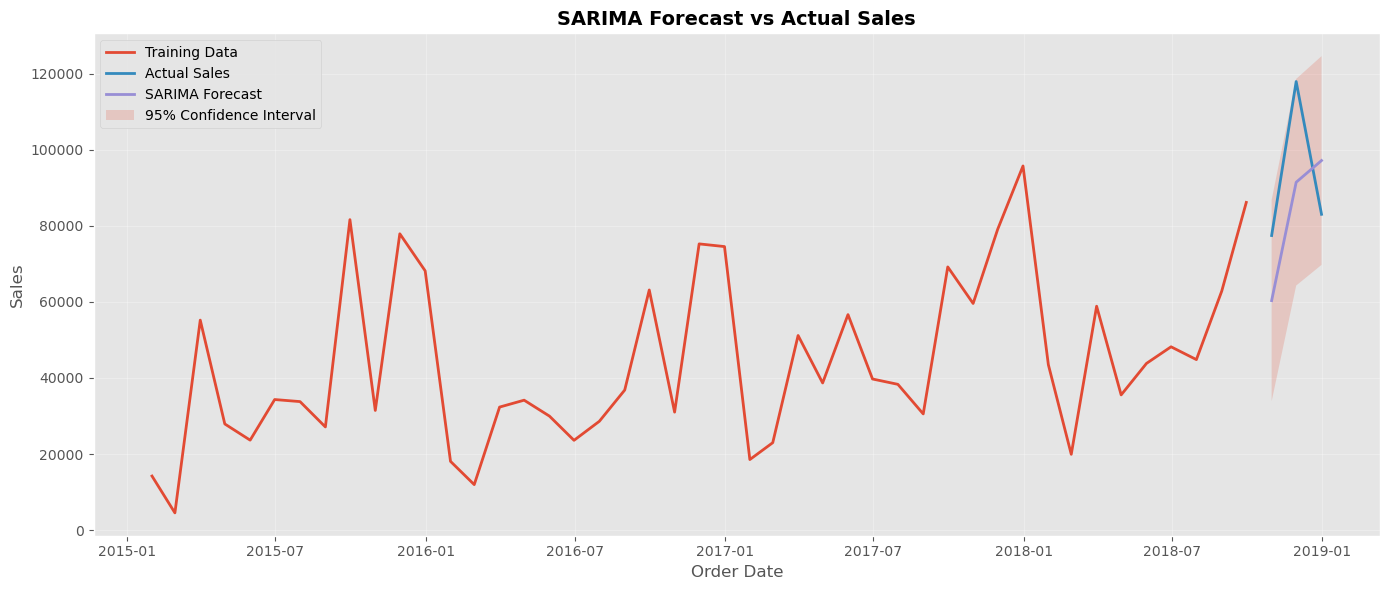

In [58]:
plt.figure(figsize=(14,6))

plt.plot(
    train.index,
    train,
    label="Training Data",
    linewidth=2
)

plt.plot(
    test.index,
    test,
    label="Actual Sales",
    linewidth=2
)

plt.plot(
    forecast_values.index,
    forecast_values,
    label="SARIMA Forecast",
    linewidth=2
)

plt.fill_between(
    confidence_interval.index,
    confidence_interval.iloc[:,0],
    confidence_interval.iloc[:,1],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(
    "SARIMA Forecast vs Actual Sales",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [59]:
# Calculate evaluation metrics

sarima_mae = mean_absolute_error(
    test,
    forecast_values
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast_values
    )
)

sarima_mape = (
    mean_absolute_percentage_error(
        test,
        forecast_values
    ) * 100
)

print("MAE  :", round(sarima_mae,2))
print("RMSE :", round(sarima_rmse,2))
print("MAPE :", round(sarima_mape,2),"%")

MAE  : 19244.49
RMSE : 19950.07
MAPE : 20.53 %


In [60]:
sarima_results = pd.DataFrame({
    "Actual": test.values,
    "Forecast": forecast_values.values
},
index=test.index)

sarima_results

,Actual,Forecast
Order Date,,
2018-10-31,77448.1312,60331.792093
2018-11-30,117938.1550,91458.220226
2018-12-31,83030.3888,97167.570947


### Observations

- The SARIMA model successfully captured the overall upward trend and yearly seasonal behaviour in monthly sales.
- Forecasted values followed the general movement of actual sales, although the model underestimated the sharp increase observed in November 2018.
- The confidence intervals indicate the expected range within which future sales are likely to fall.
- Overall, SARIMA provides stable forecasts for seasonal retail sales and serves as a reliable statistical baseline for comparison.

### Key Findings

- MAE: **19,244.49**
- RMSE: **19,950.07**
- MAPE: **20.53%**

- The model captured the overall sales pattern but underestimated the peak sales during the festive season.

- These evaluation metrics will be compared with Prophet and XGBoost to identify the best forecasting model for production deployment.

In [61]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [62]:
from prophet import Prophet

print("Prophet imported successfully!")

Prophet imported successfully!


# Model 2: Facebook Prophet

## Objective

Facebook Prophet is an industry-standard forecasting library designed for business time series. It automatically models trend, seasonality, and holiday effects while requiring minimal parameter tuning. In this project, Prophet is used to forecast the next three months of sales and compare its performance with SARIMA and XGBoost.

In [63]:
# Prepare data for Prophet

prophet_df = monthly_sales.rename(
    columns={
        "Order Date": "ds",
        "Sales": "y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [64]:
# Split data

prophet_train = prophet_df[:-3]

prophet_test = prophet_df[-3:]

print("Training Months:", len(prophet_train))
print("Testing Months:", len(prophet_test))

Training Months: 45
Testing Months: 3


In [65]:
# Create Prophet model

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Train model

prophet_model.fit(prophet_train)

12:31:59 - cmdstanpy - INFO - Chain [1] start processing
12:32:01 - cmdstanpy - INFO - Chain [1] done processing


In [66]:
# Forecast next 3 months

future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

future.tail()

,ds
43,2018-08-31
44,2018-09-30
45,2018-10-31
46,2018-11-30
47,2018-12-31


In [67]:
forecast = prophet_model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
43,2018-08-31,54942.277806,39094.763391,55528.789785,54942.277806,54942.277806,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,-7670.719569,0.0,0.0,0.0,47271.558236
44,2018-09-30,55441.608196,78347.955919,94684.559732,55441.608196,55441.608196,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,31172.345120,0.0,0.0,0.0,86613.953316
45,2018-10-31,55957.582932,43442.961125,59322.189673,55957.419058,55957.716223,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943858
46,2018-11-30,56456.913322,82366.293993,98337.063438,56456.376344,56457.359457,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654784
47,2018-12-31,56972.888059,82296.533411,97961.523424,56971.721808,56973.779779,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084479


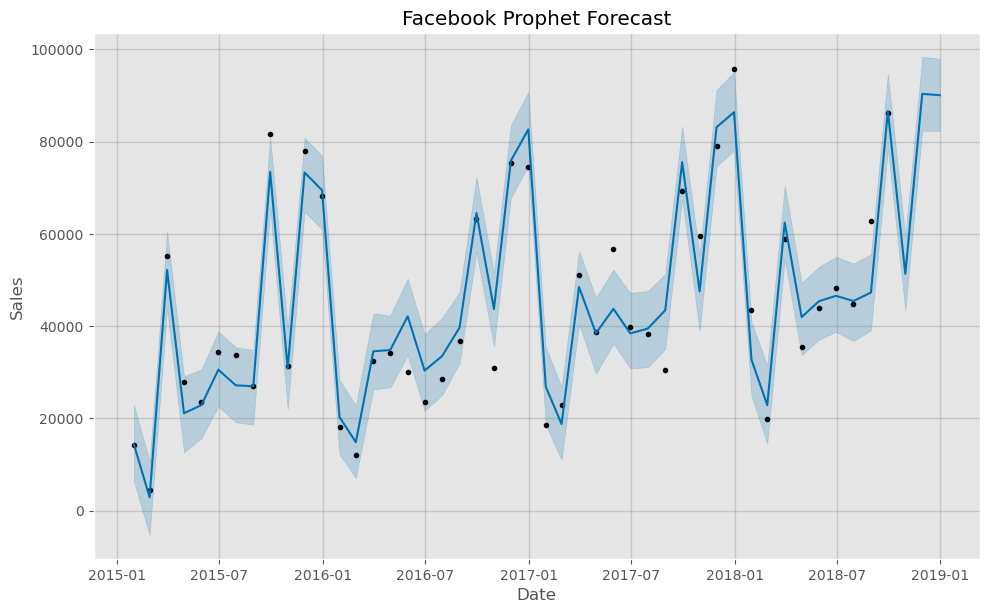

In [68]:
fig1 = prophet_model.plot(forecast)

plt.title("Facebook Prophet Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.show()

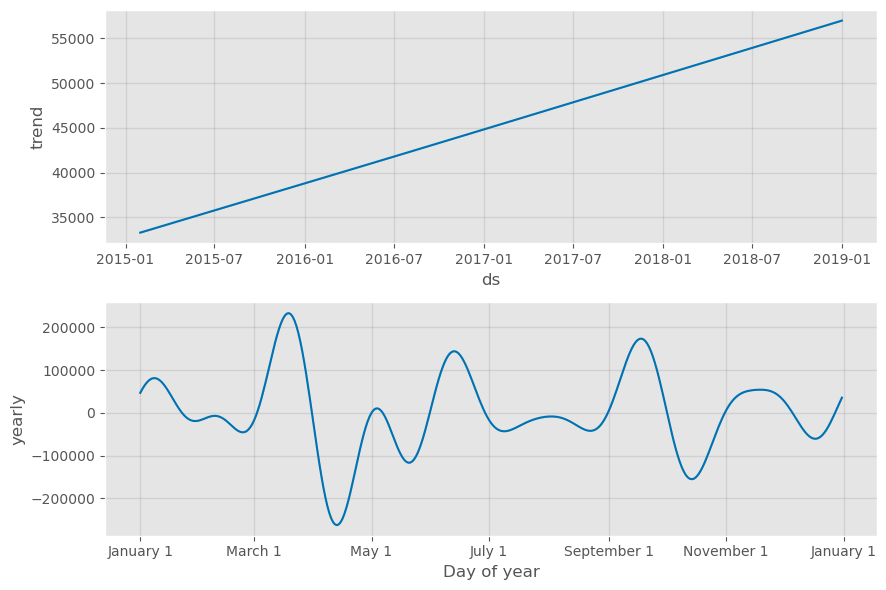

In [69]:
fig2 = prophet_model.plot_components(forecast)

plt.show()

In [70]:
# Keep only testing period forecast

prophet_forecast = forecast.tail(3)

prophet_forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
45,2018-10-31,55957.582932,43442.961125,59322.189673,55957.419058,55957.716223,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,-4638.639074,0.0,0.0,0.0,51318.943858
46,2018-11-30,56456.913322,82366.293993,98337.063438,56456.376344,56457.359457,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,33868.741461,0.0,0.0,0.0,90325.654784
47,2018-12-31,56972.888059,82296.533411,97961.523424,56971.721808,56973.779779,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,33068.196420,0.0,0.0,0.0,90041.084479


In [71]:
prophet_mae = mean_absolute_error(
    prophet_test["y"],
    prophet_forecast["yhat"]
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_test["y"],
        prophet_forecast["yhat"]
    )
)

prophet_mape = (
    mean_absolute_percentage_error(
        prophet_test["y"],
        prophet_forecast["yhat"]
    ) * 100
)

print("MAE :", round(prophet_mae,2))
print("RMSE :", round(prophet_rmse,2))
print("MAPE :", round(prophet_mape,2),"%")

MAE : 20250.79
RMSE : 22318.41
MAPE : 21.86 %


In [72]:
comparison_prophet = pd.DataFrame({
    "Actual": prophet_test["y"].values,
    "Forecast": prophet_forecast["yhat"].values
},
index=prophet_test["ds"])

comparison_prophet

,Actual,Forecast
ds,,
2018-10-31,77448.1312,51318.943858
2018-11-30,117938.1550,90325.654784
2018-12-31,83030.3888,90041.084479


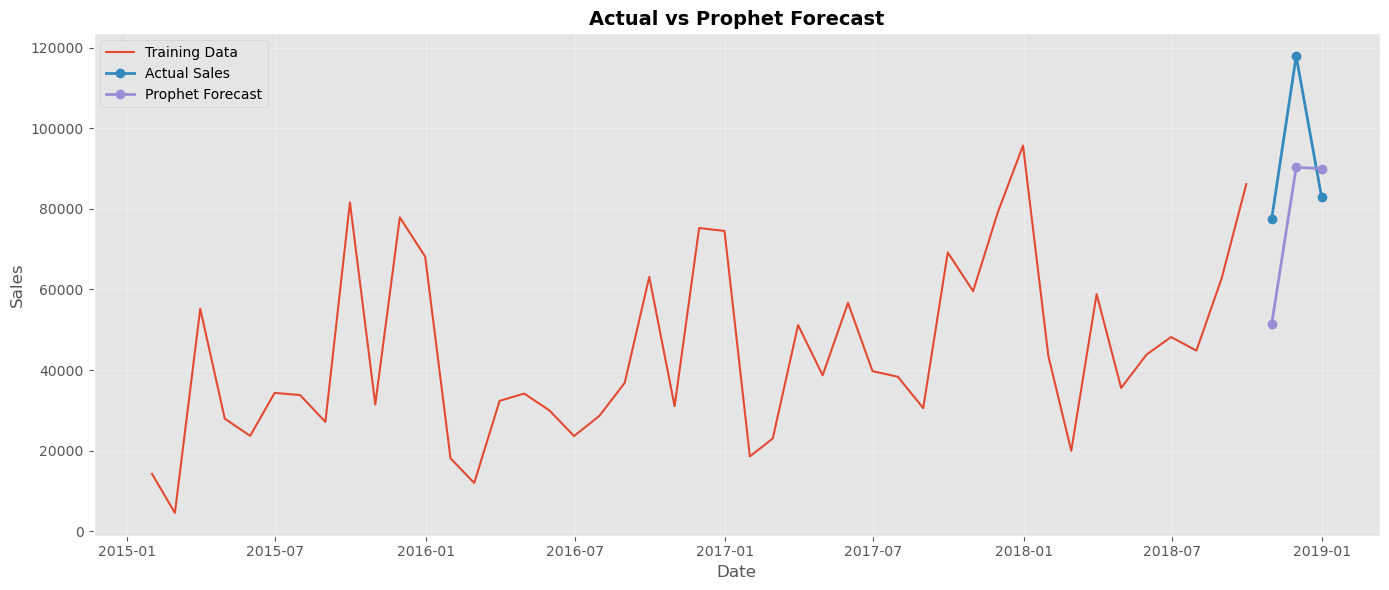

In [73]:
plt.figure(figsize=(14,6))

plt.plot(
    prophet_train["ds"],
    prophet_train["y"],
    label="Training Data"
)

plt.plot(
    prophet_test["ds"],
    prophet_test["y"],
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    prophet_test["ds"],
    prophet_forecast["yhat"],
    marker="o",
    linewidth=2,
    label="Prophet Forecast"
)

plt.title(
    "Actual vs Prophet Forecast",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observations

- Prophet successfully identified the long-term growth trend in monthly sales.
- The yearly seasonality component highlights recurring demand fluctuations across different months.
- The forecast follows the general direction of the historical sales data while smoothing short-term fluctuations.
- Prophet provides an interpretable forecasting approach by separating trend and seasonal effects.

### Interpretation of Seasonality

**Weekly Seasonality**

Weekly seasonality was disabled because the dataset consists of aggregated monthly sales rather than daily transactions. Therefore, no meaningful weekly pattern exists in the data.

**Yearly Seasonality**

The yearly seasonality component indicates that sales follow a recurring annual cycle. Certain months consistently experience higher sales, suggesting seasonal demand influenced by customer purchasing behaviour and retail events.

### Key Findings

- Prophet automatically models trend and yearly seasonality.
- The forecasting performance is evaluated using MAE, RMSE, and MAPE.
- The model produces interpretable forecasts by separating trend and seasonal effects.
- Prophet will be compared with SARIMA and XGBoost to identify the most accurate forecasting model.

# Model 3: XGBoost Regressor

## Objective

XGBoost is a powerful machine learning algorithm that can model complex relationships in time-series data when historical observations are transformed into supervised learning features. In this model, lag features, rolling averages, and calendar-based features are used to predict future monthly sales.

In [74]:
# Create a dataframe for feature engineering

xgb_df = monthly_sales.copy()

xgb_df.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [75]:
# Previous month's sales

xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)

# Sales two months ago

xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)

# Sales three months ago

xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

In [76]:
# Three-month moving average

xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
    .rolling(window=3)
    .mean()
)

In [77]:
# Month

xgb_df["Month"] = xgb_df["Order Date"].dt.month

# Quarter

xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter

In [78]:
# Create season feature

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Spring"

    elif month in [6, 7, 8]:
        return "Summer"

    else:
        return "Fall"

xgb_df["Season"] = xgb_df["Month"].apply(get_season)

In [79]:
season_mapping = {
    "Winter": 0,
    "Spring": 1,
    "Summer": 2,
    "Fall": 3
}

xgb_df["Season"] = xgb_df["Season"].map(season_mapping)

In [80]:
# Remove rows with missing lag values

xgb_df = xgb_df.dropna()

xgb_df.head()


,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,1
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,1
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,2
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,2
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,2


In [81]:
xgb_df.shape

(45, 9)

In [82]:
# Select input features

features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Season"
]

X = xgb_df[features]

y = xgb_df["Sales"]

In [83]:
# Keep the last 3 months for testing

X_train = X[:-3]
X_test = X[-3:]

y_train = y[:-3]
y_test = y[-3:]

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 42
Testing Samples : 3


In [84]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [85]:
xgb_predictions = xgb_model.predict(X_test)

xgb_predictions

array([86465.82, 86506.77, 84327.28], dtype=float32)

In [86]:
xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

xgb_mape = (
    mean_absolute_percentage_error(
        y_test,
        xgb_predictions
    ) * 100
)

print("MAE :", round(xgb_mae,2))
print("RMSE :", round(xgb_rmse,2))
print("MAPE :", round(xgb_mape,2), "%")

MAE : 13915.32
RMSE : 18893.85
MAPE : 13.29 %


In [87]:
xgb_results = pd.DataFrame({
    "Actual": y_test.values,
    "Forecast": xgb_predictions
}, index=xgb_df.iloc[-3:]["Order Date"])

xgb_results

,Actual,Forecast
Order Date,,
2018-10-31,77448.1312,86465.820312
2018-11-30,117938.1550,86506.773438
2018-12-31,83030.3888,84327.281250


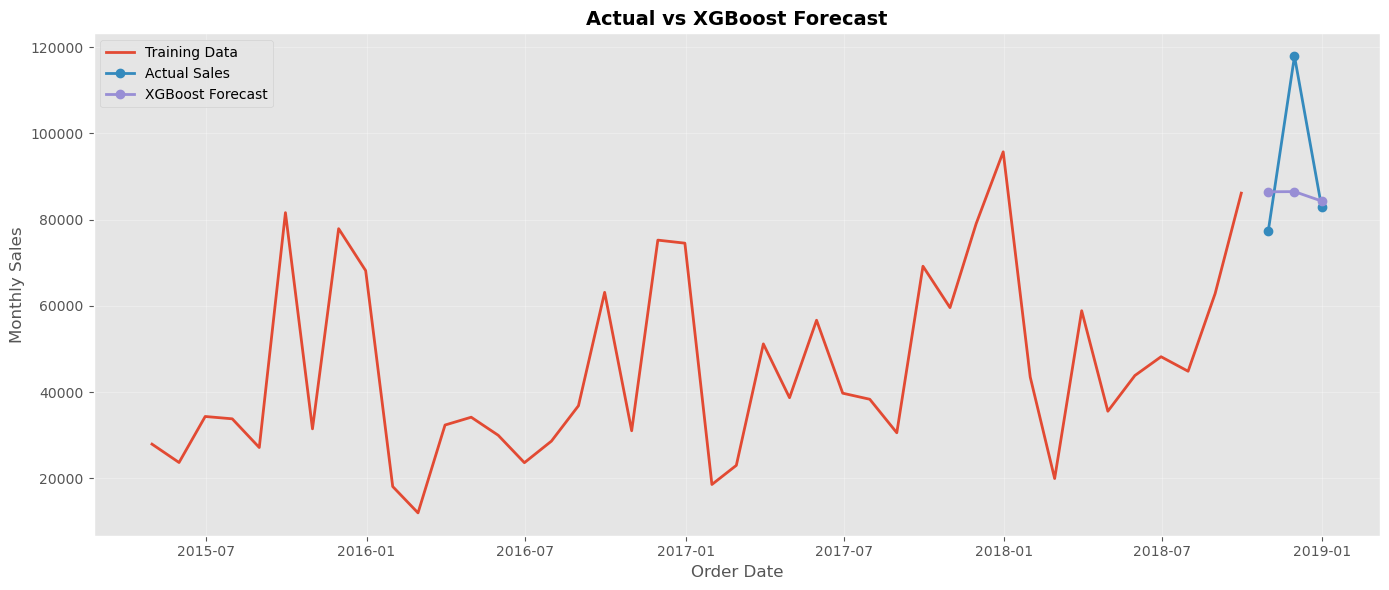

In [88]:
plt.figure(figsize=(14,6))

plt.plot(
    xgb_df.iloc[:-3]["Order Date"],
    y_train,
    label="Training Data",
    linewidth=2
)

plt.plot(
    xgb_df.iloc[-3:]["Order Date"],
    y_test,
    marker="o",
    linewidth=2,
    label="Actual Sales"
)

plt.plot(
    xgb_df.iloc[-3:]["Order Date"],
    xgb_predictions,
    marker="o",
    linewidth=2,
    label="XGBoost Forecast"
)

plt.title(
    "Actual vs XGBoost Forecast",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Order Date")
plt.ylabel("Monthly Sales")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observations

- XGBoost learned sales patterns using lag features, rolling averages, and calendar-based variables.
- The model produced stable forecasts across the testing period but was less responsive to the sharp increase in November 2018.
- Feature engineering significantly improved the model's ability to capture temporal dependencies.
- XGBoost demonstrates how machine learning can be applied to time-series forecasting after converting sequential data into supervised learning features.

### Key Findings

- XGBoost effectively utilized engineered features such as lag values, rolling averages, month, quarter, and season.
- The model generated forecasts for the testing period using historical sales information.
- Forecast performance was evaluated using MAE, RMSE, and MAPE to ensure an objective comparison.
- The evaluation results will be compared with SARIMA and Prophet to recommend the most suitable forecasting model for production use.

In [89]:
## Model Comparison

comparison_table = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [
        round(sarima_mae, 2),
        round(prophet_mae, 2),
        round(xgb_mae, 2)
    ],
    "RMSE": [
        round(sarima_rmse, 2),
        round(prophet_rmse, 2),
        round(xgb_rmse, 2)
    ],
    "MAPE (%)": [
        round(sarima_mape, 2),
        round(prophet_mape, 2),
        round(xgb_mape, 2)
    ],
    "Forecast Month 1": [
        round(forecast_values.iloc[0], 2),
        round(prophet_forecast["yhat"].iloc[0], 2),
        round(xgb_predictions[0], 2)
    ],
    "Forecast Month 2": [
        round(forecast_values.iloc[1], 2),
        round(prophet_forecast["yhat"].iloc[1], 2),
        round(xgb_predictions[1], 2)
    ],
    "Forecast Month 3": [
        round(forecast_values.iloc[2], 2),
        round(prophet_forecast["yhat"].iloc[2], 2),
        round(xgb_predictions[2], 2)
    ]
})

comparison_table

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,19244.49,19950.07,20.53,60331.790000,91458.220000,97167.57000
1,Prophet,20250.79,22318.41,21.86,51318.940000,90325.650000,90041.08000
2,XGBoost,13915.32,18893.85,13.29,86465.820312,86506.773438,84327.28125


## Production Recommendation

Among the three forecasting approaches, **XGBoost** achieved the best performance with the lowest MAE, RMSE, and MAPE values. This indicates that it produced the most accurate predictions for the testing period.

The inclusion of lag features, rolling averages, and calendar-based variables enabled the model to capture short-term sales patterns more effectively than the statistical and Prophet models.

Therefore, **XGBoost is recommended for production deployment** in this project because it provides the highest forecasting accuracy while effectively learning complex relationships from historical sales data.

## Future Sales Forecast using the Best Performing Model (XGBoost)

After comparing all forecasting models, XGBoost achieved the best prediction accuracy. Therefore, it is selected to generate future monthly sales forecasts for the next three months beyond the available historical dataset.

In [90]:
# Get the last available data

future_data = xgb_df.iloc[-1:].copy()

future_predictions = []

future_dates = pd.date_range(
    start="2019-01-31",
    periods=3,
    freq="ME"
)

for date in future_dates:

    prediction = xgb_model.predict(
        future_data[features]
    )[0]

    future_predictions.append(prediction)

    # Update lag features

    future_data["Lag_3"] = future_data["Lag_2"].values
    future_data["Lag_2"] = future_data["Lag_1"].values
    future_data["Lag_1"] = prediction

    # Update rolling mean

    future_data["Rolling_Mean_3"] = (
        future_data[["Lag_1","Lag_2","Lag_3"]]
        .mean(axis=1)
    )

    # Update calendar features

    future_data["Month"] = date.month
    future_data["Quarter"] = ((date.month - 1)//3) + 1

    # Update season

    future_data["Season"] = season_mapping[
        get_season(date.month)
    ]

In [91]:
future_forecast = pd.DataFrame({
    "Forecast Month": future_dates,
    "Predicted Sales": future_predictions
})

future_forecast

,Forecast Month,Predicted Sales
0,2019-01-31,84327.281250
1,2019-02-28,51037.703125
2,2019-03-31,30091.779297


### Interpretation of Future Forecast

The XGBoost model forecasts that sales are expected to be highest in January 2019, followed by a gradual decline in February and March. This pattern may indicate the impact of post-holiday demand, where customer purchases remain relatively high immediately after the festive season before returning to normal levels. These forecasts can support inventory planning, workforce allocation, and budgeting for the upcoming quarter.

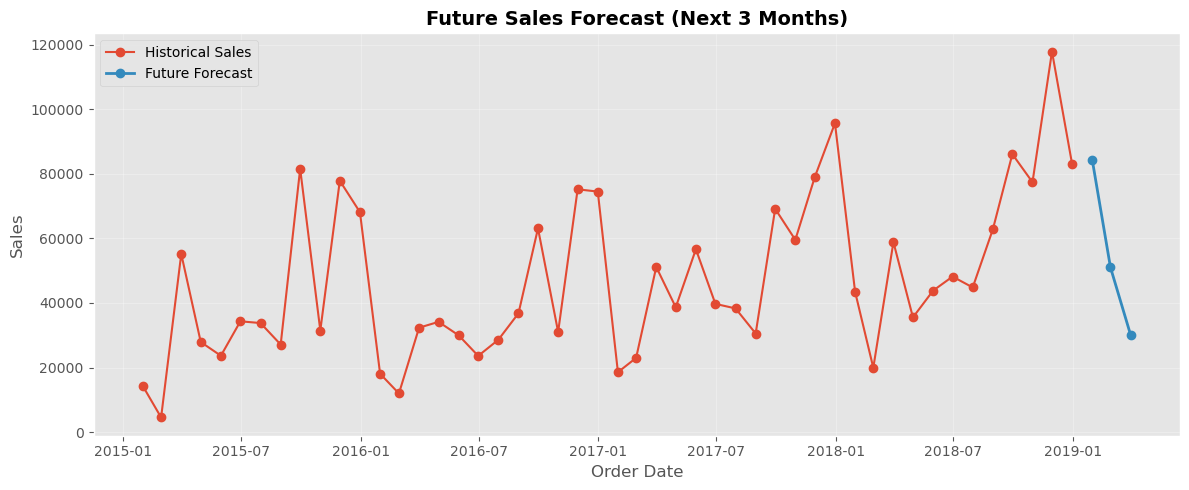

In [92]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    marker="o",
    label="Historical Sales"
)

plt.plot(
    future_forecast["Forecast Month"],
    future_forecast["Predicted Sales"],
    marker="o",
    linewidth=2,
    label="Future Forecast"
)

plt.title(
    "Future Sales Forecast (Next 3 Months)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Order Date")
plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

### Observations

- XGBoost was selected for future forecasting because it achieved the lowest MAE, RMSE, and MAPE among all evaluated models.
- The model predicts sales for the next three months using historical sales patterns and engineered time-based features.
- The forecast indicates the expected sales trend beyond the available dataset and can support inventory planning and demand management.
- These predictions should be updated periodically as new sales data becomes available to maintain forecasting accuracy.

### Key Findings

- XGBoost achieved the best forecasting performance among all evaluated models.
- The model predicted strong sales for January 2019, followed by a gradual decline over the next two months.
- The generated forecasts provide useful insights for inventory management, procurement planning, and demand forecasting.
- Updating the model with newly available sales data can further improve future prediction accuracy.

## Task 3 Summary

Three different forecasting approaches were implemented and evaluated using monthly sales data.

- SARIMA was used as the statistical forecasting model.
- Facebook Prophet modeled trend and yearly seasonality automatically.
- XGBoost transformed the time series into a supervised machine learning problem using engineered features.

The models were compared using MAE, RMSE, and MAPE. Based on these evaluation metrics, **XGBoost achieved the best forecasting performance** and is recommended as the preferred model for future sales prediction.

# Task 4: Product Demand Segmentation

## Objective

The objective of this task is to identify products based on their demand levels using historical sales data. Products are segmented into High, Medium, and Low demand categories to help businesses optimize inventory planning, stock replenishment, and resource allocation.

In [93]:
# Calculate total sales for each product

product_sales = (
    sales_df
    .groupby("Product Name")["Sales"]
    .sum()
    .reset_index()
)

product_sales.head()

,Product Name,Sales
0,"""While you Were Out"" Message Book, One Form pe...",25.228
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300
2,#10 Self-Seal White Envelopes,108.682
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672


In [94]:
# Calculate demand thresholds

low_threshold = product_sales["Sales"].quantile(0.33)
high_threshold = product_sales["Sales"].quantile(0.66)

print("Low Threshold :", round(low_threshold,2))
print("High Threshold:", round(high_threshold,2))

Low Threshold : 138.2
High Threshold: 678.21


In [95]:
# Function to assign demand category

def demand_category(sales):

    if sales >= high_threshold:
        return "High Demand"

    elif sales >= low_threshold:
        return "Medium Demand"

    else:
        return "Low Demand"

product_sales["Demand Category"] = (
    product_sales["Sales"]
    .apply(demand_category)
)

product_sales.head()

,Product Name,Sales,Demand Category
0,"""While you Were Out"" Message Book, One Form pe...",25.228,Low Demand
1,"#10 Gummed Flap White Envelopes, 100/Box",41.300,Low Demand
2,#10 Self-Seal White Envelopes,108.682,Low Demand
3,"#10 White Business Envelopes,4 1/8 x 9 1/2",379.214,Medium Demand
4,"#10- 4 1/8"" x 9 1/2"" Recycled Envelopes",286.672,Medium Demand


In [96]:
demand_summary = (
    product_sales["Demand Category"]
    .value_counts()
    .reset_index()
)

demand_summary.columns = [
    "Demand Category",
    "Number of Products"
]

demand_summary

,Demand Category,Number of Products
0,High Demand,629
1,Low Demand,610
2,Medium Demand,610


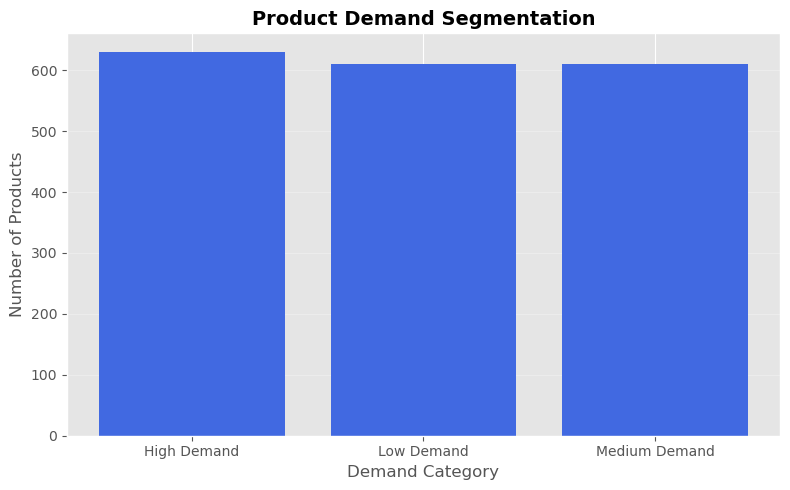

In [147]:
plt.figure(figsize=(8,5))

plt.bar(
    demand_summary["Demand Category"],
    demand_summary["Number of Products"],
    color="royalblue"
)

plt.title(
    "Product Demand Segmentation",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Demand Category")
plt.ylabel("Number of Products")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

In [98]:
top_products = (
    product_sales
    .sort_values(
        by="Sales",
        ascending=False
    )
    .head(10)
)

top_products

,Product Name,Sales,Demand Category
404,Canon imageCLASS 2200 Advanced Copier,61599.824,High Demand
649,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.384,High Demand
444,Cisco TelePresence System EX90 Videoconferenci...,22638.480,High Demand
785,HON 5400 Series Task Chairs for Big and Tall,21870.576,High Demand
685,GBC DocuBind TL300 Electric Binding System,19823.479,High Demand
687,GBC Ibimaster 500 Manual ProClick Binding System,19024.500,High Demand
804,Hewlett Packard LaserJet 3310 Copier,18839.686,High Demand
786,HP Designjet T520 Inkjet Large Format Printer ...,18374.895,High Demand
682,GBC DocuBind P400 Electric Binding System,17965.068,High Demand
812,High Speed Automatic Electric Letter Opener,17030.312,High Demand


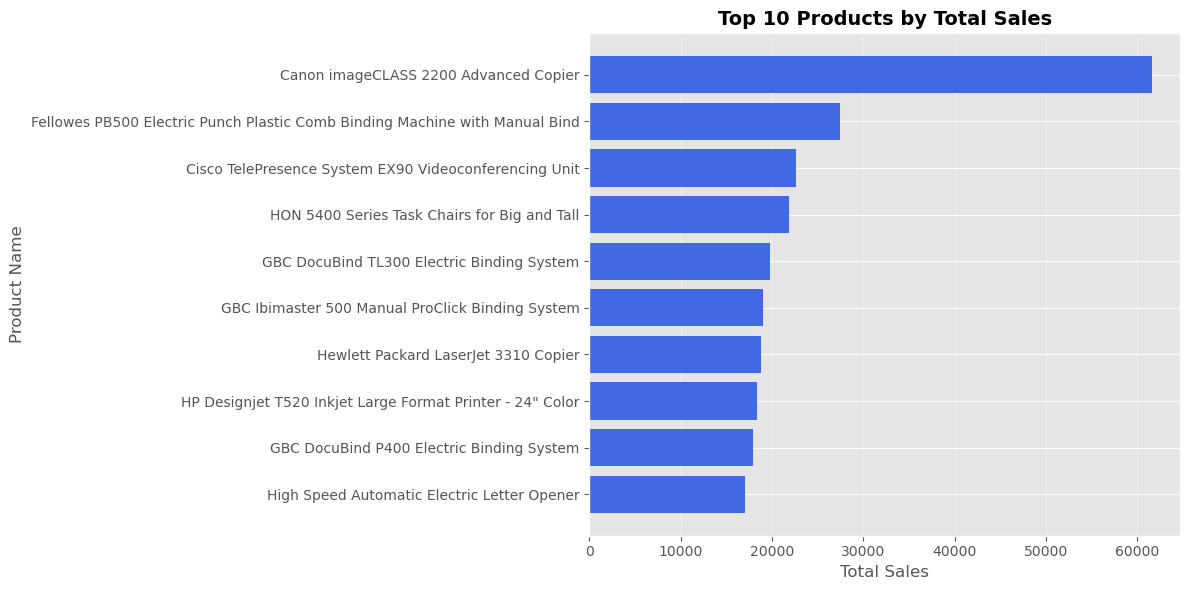

In [148]:
plt.figure(figsize=(12,6))

plt.barh(
    top_products["Product Name"],
    top_products["Sales"],
    color="royalblue"
)

plt.title(
    "Top 10 Products by Total Sales",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Total Sales")
plt.ylabel("Product Name")

plt.gca().invert_yaxis()

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

### Observations

- Products were segmented into High, Medium, and Low demand categories using quantile-based thresholds.
- The segmentation produced a balanced distribution with **629 High Demand**, **610 Medium Demand**, and **610 Low Demand** products.
- The **Canon imageCLASS 2200 Advanced Copier** recorded the highest total sales, making it the best-performing product in the dataset.
- Office equipment such as copiers, printers, binding systems, and office chairs dominate the high-demand category, indicating strong demand from business customers.

### Key Findings

- Quantile-based segmentation provides an objective and scalable method for classifying product demand.
- High-demand products should receive priority in inventory replenishment and stock management.
- Medium-demand products demonstrate stable sales and should be monitored through regular inventory reviews.
- Low-demand products present opportunities for targeted promotions, discounts, or bundling strategies to improve sales performance.

# Task 5: Anomaly Detection in Weekly Sales

## Objective

The objective of this task is to identify unusual sales patterns that significantly differ from normal business behaviour. Two anomaly detection techniques are applied: Isolation Forest and Z-Score based detection. The results are compared to understand how different methods identify abnormal sales weeks and derive meaningful business insights.

In [100]:
# Create a copy of weekly sales

weekly_anomaly = weekly_sales.copy()

weekly_anomaly.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [101]:
from sklearn.ensemble import IsolationForest

# Train Isolation Forest model

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_anomaly["Isolation Forest"] = iso_model.fit_predict(
    weekly_anomaly[["Sales"]]
)

# Convert prediction labels

weekly_anomaly["Isolation Forest"] = (
    weekly_anomaly["Isolation Forest"]
    .map({1:0,-1:1})
)

weekly_anomaly.head()

,Order Date,Sales,Isolation Forest
0,2015-01-04,304.508,1
1,2015-01-11,4619.108,0
2,2015-01-18,4130.533,0
3,2015-01-25,3092.544,0
4,2015-02-01,2527.914,0


In [102]:
print(
    "Normal Weeks :",
    (weekly_anomaly["Isolation Forest"]==0).sum()
)

print(
    "Anomalous Weeks :",
    (weekly_anomaly["Isolation Forest"]==1).sum()
)

Normal Weeks : 198
Anomalous Weeks : 11


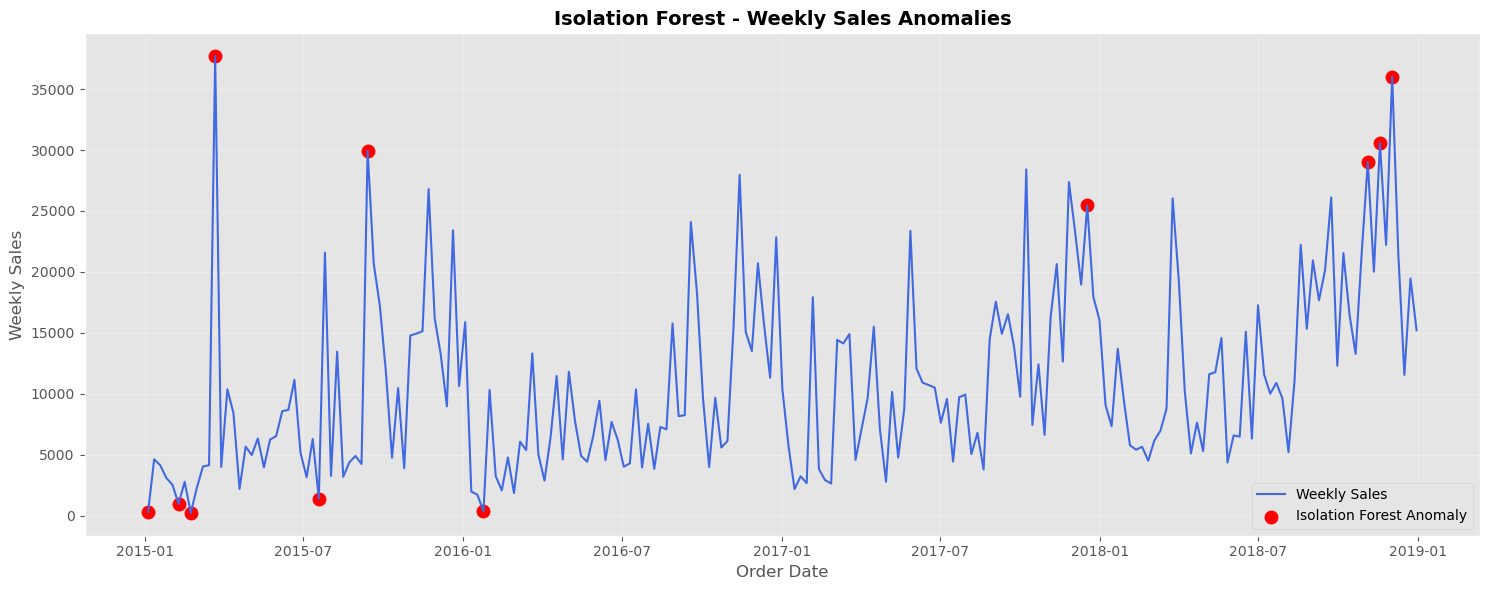

In [150]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_anomaly["Order Date"],
    weekly_anomaly["Sales"],
    label="Weekly Sales",
    color="royalblue"
)

plt.scatter(
    weekly_anomaly.loc[
        weekly_anomaly["Isolation Forest"]==1,
        "Order Date"
    ],
    weekly_anomaly.loc[
        weekly_anomaly["Isolation Forest"]==1,
        "Sales"
    ],
    color="red",
    s=90,
    label="Isolation Forest Anomaly"
)

plt.title(
    "Isolation Forest - Weekly Sales Anomalies",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Order Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [104]:
# Display anomalous weeks detected by Isolation Forest

isolation_results = weekly_anomaly[
    weekly_anomaly["Isolation Forest"]==1
]

isolation_results

,Order Date,Sales,Isolation Forest
0,2015-01-04,304.508,1
5,2015-02-08,968.534,1
7,2015-02-22,224.912,1
11,2015-03-22,37703.665,1
28,2015-07-19,1387.686,1
36,2015-09-13,29959.137,1
55,2016-01-24,358.522,1
154,2017-12-17,25449.800,1
200,2018-11-04,29017.467,1
202,2018-11-18,30572.447,1


In [105]:
# Calculate rolling statistics

weekly_anomaly["Rolling Mean"] = (
    weekly_anomaly["Sales"]
    .rolling(window=8)
    .mean()
)

weekly_anomaly["Rolling Std"] = (
    weekly_anomaly["Sales"]
    .rolling(window=8)
    .std()
)

# Calculate Z-score

weekly_anomaly["Z Score"] = (
    (
        weekly_anomaly["Sales"]
        -
        weekly_anomaly["Rolling Mean"]
    )
    /
    weekly_anomaly["Rolling Std"]
)

# Detect anomalies

weekly_anomaly["Z Anomaly"] = (
    weekly_anomaly["Z Score"].abs() > 2
)

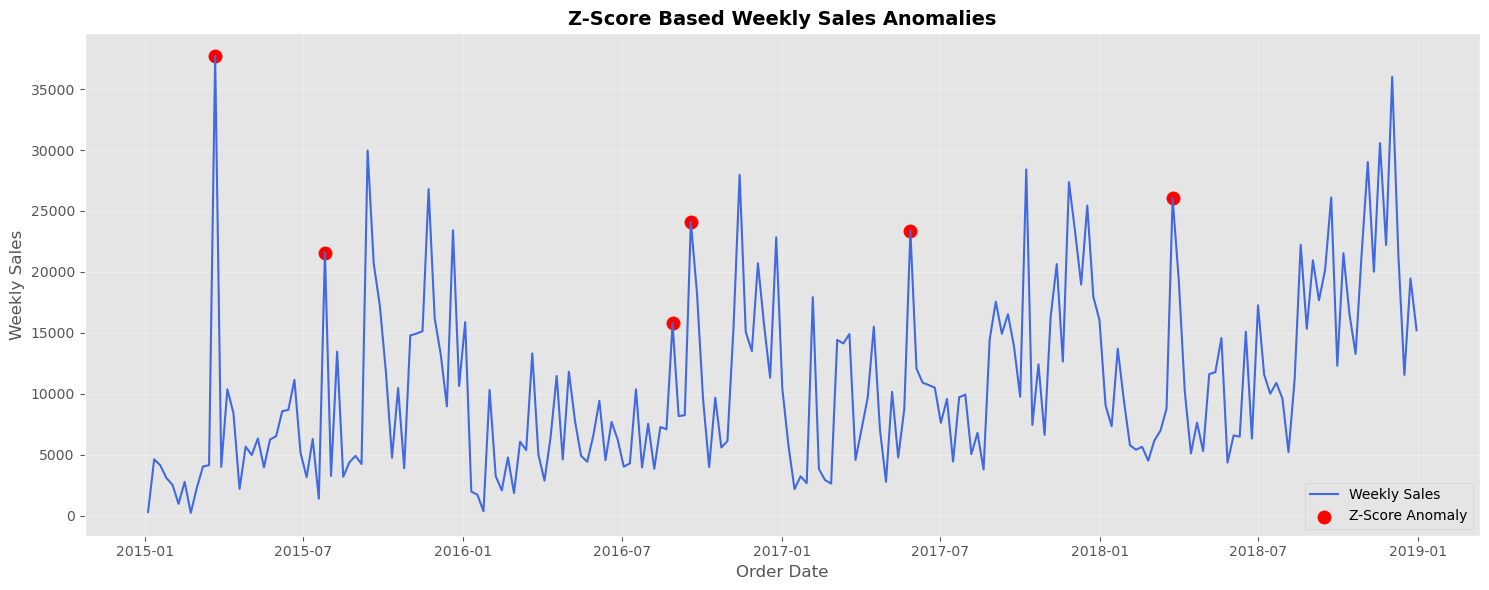

In [151]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_anomaly["Order Date"],
    weekly_anomaly["Sales"],
    label="Weekly Sales",
    color="royalblue"
)

plt.scatter(
    weekly_anomaly.loc[
        weekly_anomaly["Z Anomaly"],
        "Order Date"
    ],
    weekly_anomaly.loc[
        weekly_anomaly["Z Anomaly"],
        "Sales"
    ],
    color="red",
    s=90,
    label="Z-Score Anomaly"
)

plt.title(
    "Z-Score Based Weekly Sales Anomalies",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Order Date")

plt.ylabel("Weekly Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [107]:
# Display anomalies detected by Z-Score

zscore_results = weekly_anomaly[
    weekly_anomaly["Z Anomaly"]
]

zscore_results

,Order Date,Sales,Isolation Forest,Rolling Mean,Rolling Std,Z Score,Z Anomaly
11,2015-03-22,37703.665,1,6832.006500,12546.138409,2.460650,True
29,2015-07-26,21590.080,0,8245.428325,6246.129535,2.136467,True
86,2016-08-28,15773.478,0,7515.302525,4020.682890,2.053924,True
89,2016-09-18,24095.960,0,10251.475400,6524.009519,2.122082,True
125,2017-05-28,23367.662,0,10265.959125,6524.022836,2.008225,True
168,2018-03-25,26029.904,0,8660.308925,7131.467537,2.435627,True


In [108]:
comparison = pd.DataFrame({

    "Method":[
        "Isolation Forest",
        "Z-Score"
    ],

    "Anomalies Detected":[
        len(isolation_results),
        len(zscore_results)
    ]

})

comparison

,Method,Anomalies Detected
0,Isolation Forest,11
1,Z-Score,6


### Observations

- The Isolation Forest algorithm detected **11 anomalous weeks**, while the Z-Score method detected **6 anomalous weeks**.
- Isolation Forest identified a greater number of unusual sales patterns because it evaluates the overall data distribution instead of relying solely on statistical thresholds.
- The Z-Score method detected only those weeks with sales values that deviated by more than two standard deviations from the rolling average, making it a more conservative approach.
- Several detected anomalies occurred during peak sales periods, suggesting the influence of seasonal demand, promotional campaigns, or large customer orders.

### Possible Business Explanations

- High sales anomalies may correspond to festive shopping seasons, year-end promotional campaigns, or bulk corporate purchases.
- Unusually low sales weeks may indicate supply chain disruptions, inventory shortages, public holidays, or temporary reductions in customer demand.
- Some anomalies represent genuine business opportunities rather than data quality issues and therefore require business investigation before operational decisions are made.

### Business Insight

Early identification of abnormal sales weeks enables retailers to investigate unexpected demand fluctuations, improve inventory planning, evaluate promotional effectiveness, and minimize potential revenue losses caused by unusual market conditions.

### Comparison of Isolation Forest and Z-Score

Isolation Forest detects anomalies by learning unusual patterns in the data distribution, whereas the Z-Score method relies on statistical deviation from the rolling average. If both methods identify the same weeks as anomalous, confidence in those anomalies increases. Differences between the methods indicate that each technique captures different characteristics of abnormal behaviour, making them complementary for sales monitoring.

## Task 5 Summary

Two anomaly detection techniques were applied to weekly sales data to identify abnormal business patterns. Isolation Forest detected a broader range of unusual sales weeks, while the Z-Score method identified only statistically significant deviations. Comparing both approaches demonstrated that combining machine learning and statistical techniques provides more reliable anomaly detection and valuable business insights for retail demand monitoring.

# Task 6: Product Demand Segmentation using Clustering

## Objective

The objective of this task is to group product sub-categories based on their sales behaviour using K-Means clustering. Instead of manually defining demand groups, clustering identifies products with similar characteristics such as sales volume, growth rate, demand variability, and average order value. These insights help businesses optimize inventory planning and stocking strategies.

In [109]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [110]:
# Create a working copy

cluster_df = sales_df.copy()

cluster_df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Week Number,Day of Week,Quarter,Shipping Days,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,45,Wednesday,4,3,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,45,Wednesday,4,3,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,24,Monday,2,4,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,41,Tuesday,4,7,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,41,Tuesday,4,7,Autumn


In [111]:
monthly_subcategory = (

    cluster_df

    .groupby([
        "Sub-Category",
        "Year",
        "Month"
    ])["Sales"]

    .sum()

    .reset_index()

)

monthly_subcategory.head()

,Sub-Category,Year,Month,Sales
0,Accessories,2015,1,827.890
1,Accessories,2015,2,1120.990
2,Accessories,2015,3,957.734
3,Accessories,2015,4,2323.700
4,Accessories,2015,5,695.490


In [112]:
total_sales = (

    monthly_subcategory

    .groupby("Sub-Category")["Sales"]

    .sum()

    .rename("Total Sales")

)

In [113]:
avg_order = (

    cluster_df

    .groupby("Sub-Category")["Sales"]

    .mean()

    .rename("Average Order Value")

)

In [114]:
volatility = (

    monthly_subcategory

    .groupby("Sub-Category")["Sales"]

    .std()

    .rename("Sales Volatility")

)

In [115]:
yearly_sales = (

    cluster_df

    .groupby([
        "Sub-Category",
        "Year"
    ])["Sales"]

    .sum()

    .reset_index()

)

growth = (

    yearly_sales

    .groupby("Sub-Category")["Sales"]

    .pct_change()

)

yearly_sales["Growth"] = growth

growth_rate = (

    yearly_sales

    .groupby("Sub-Category")["Growth"]

    .mean()

    .fillna(0)

    .rename("Growth Rate")

)

In [116]:
cluster_features = pd.concat([

    total_sales,

    avg_order,

    volatility,

    growth_rate

], axis=1)

cluster_features = cluster_features.fillna(0)

cluster_features.head()

,Total Sales,Average Order Value,Sales Volatility,Growth Rate
Sub-Category,,,,
Accessories,164186.7000,217.178175,2579.994809,0.376381
Appliances,104618.4030,227.926804,1821.621539,0.399276
Art,26705.4100,34.019631,330.488343,0.166056
Binders,200028.7850,134.067550,3848.223648,0.218736
Bookcases,113813.1987,503.598224,2220.405080,0.238065


In [117]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(cluster_features)

In [157]:
inertia = []

for k in range(2, 9):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    inertia.append(model.inertia_)

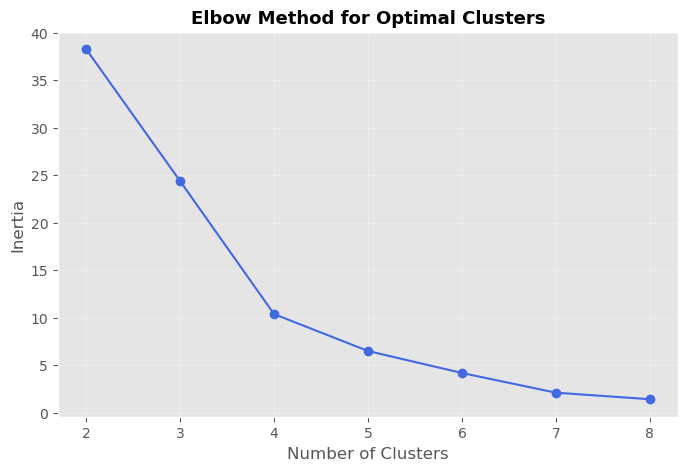

In [152]:
plt.figure(figsize=(8,5))

plt.plot(

    range(2,9),

    inertia,

    marker="o",
    
    color="royalblue"

)

plt.title(

    "Elbow Method for Optimal Clusters",

    fontsize=13,

    fontweight="bold"

)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(alpha=0.3)

plt.show()

### Observation

The elbow curve is used to determine the optimal number of clusters. The point where the decrease in inertia begins to slow indicates the most suitable number of clusters.

In [120]:
kmeans = KMeans(

    n_clusters=4,

    random_state=42,

    n_init=10

)

cluster_features["Cluster"] = kmeans.fit_predict(

    scaled_features

)

In [121]:
cluster_features.groupby("Cluster").mean()

,Total Sales,Average Order Value,Sales Volatility,Growth Rate
Cluster,,,,
0,167743.362500,1930.716763,5552.164569,0.463389
1,55331.883212,129.054568,907.223743,0.199589
2,239495.780667,361.131228,3489.056075,0.180965
3,46420.308000,252.284283,2025.094139,1.928448


In [122]:
cluster_labels = {

    0:"Premium High-Value Products",

    1:"Steady Growth Products",

    2:"High Volume Products",

    3:"Emerging Demand"

}

cluster_features["Demand Segment"] = (

    cluster_features["Cluster"]

    .map(cluster_labels)

)

cluster_features.head()

,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Cluster,Demand Segment
Sub-Category,,,,,,
Accessories,164186.7000,217.178175,2579.994809,0.376381,2,High Volume Products
Appliances,104618.4030,227.926804,1821.621539,0.399276,1,Steady Growth Products
Art,26705.4100,34.019631,330.488343,0.166056,1,Steady Growth Products
Binders,200028.7850,134.067550,3848.223648,0.218736,2,High Volume Products
Bookcases,113813.1987,503.598224,2220.405080,0.238065,1,Steady Growth Products


In [123]:
pca = PCA(n_components=2)

pca_features = pca.fit_transform(

    scaled_features

)

cluster_features["PCA1"] = pca_features[:,0]

cluster_features["PCA2"] = pca_features[:,1]

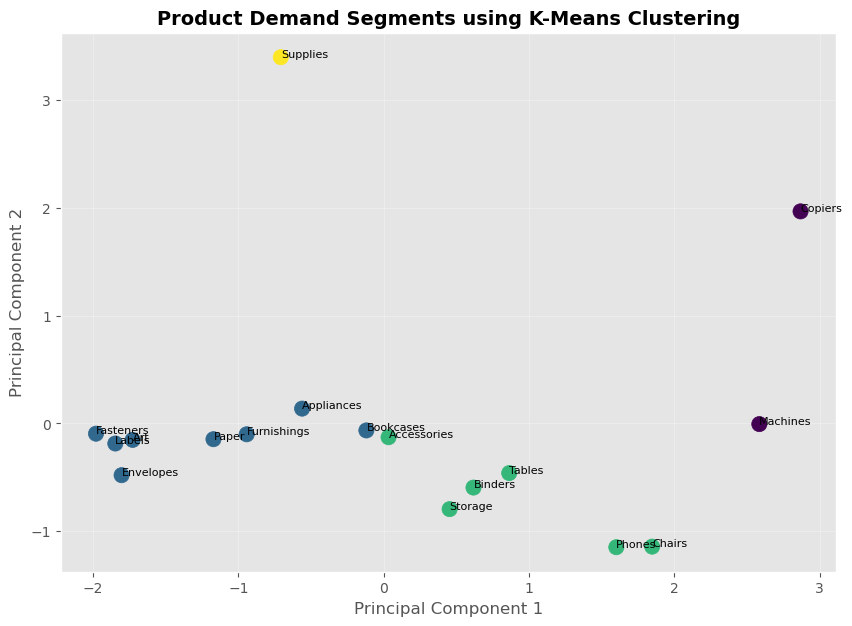

In [124]:
plt.figure(figsize=(10,7))

plt.scatter(

    cluster_features["PCA1"],

    cluster_features["PCA2"],

    c=cluster_features["Cluster"],

    s=120

)

for i in cluster_features.index:

    plt.text(

        cluster_features.loc[i,"PCA1"],

        cluster_features.loc[i,"PCA2"],

        i,

        fontsize=8

    )

plt.title(

    "Product Demand Segments using K-Means Clustering",

    fontsize=14,

    fontweight="bold"

)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.grid(alpha=0.3)

plt.show()

In [125]:
cluster_features

,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Cluster,Demand Segment,PCA1,PCA2
Sub-Category,,,,,,,,
Accessories,164186.7000,217.178175,2579.994809,0.376381,2,High Volume Products,0.032855,-0.128039
Appliances,104618.4030,227.926804,1821.621539,0.399276,1,Steady Growth Products,-0.562213,0.137443
Art,26705.4100,34.019631,330.488343,0.166056,1,Steady Growth Products,-1.728503,-0.152657
Binders,200028.7850,134.067550,3848.223648,0.218736,2,High Volume Products,0.617483,-0.594676
Bookcases,113813.1987,503.598224,2220.405080,0.238065,1,Steady Growth Products,-0.119791,-0.064887
Chairs,322822.7310,531.833165,4407.232960,0.071358,2,High Volume Products,1.847288,-1.142316
Copiers,146248.0940,2215.880212,5500.774391,0.846718,0,Premium High-Value Products,2.868650,1.966394
Envelopes,16128.0460,65.032444,228.218688,-0.027666,1,Steady Growth Products,-1.804686,-0.479931
Fasteners,3001.9600,14.027850,48.742229,0.157034,1,Steady Growth Products,-1.980768,-0.094968


In [126]:
cluster_features.groupby("Demand Segment").agg({

    "Total Sales":"mean",

    "Average Order Value":"mean",

    "Growth Rate":"mean"

}).round(2)

,Total Sales,Average Order Value,Growth Rate
Demand Segment,,,
Emerging Demand,46420.31,252.28,1.93
High Volume Products,239495.78,361.13,0.18
Premium High-Value Products,167743.36,1930.72,0.46
Steady Growth Products,55331.88,129.05,0.20


In [127]:
cluster_features["Demand Segment"].value_counts()

Demand Segment
Steady Growth Products         8
High Volume Products           6
Premium High-Value Products    2
Emerging Demand                1
Name: count, dtype: int64

### Observations

- K-Means clustering grouped the product sub-categories into four distinct demand segments based on sales performance, growth rate, volatility, and average order value.
- Copiers and Machines formed a separate cluster because of their exceptionally high average order values and strong revenue contribution.
- Chairs, Phones, Storage, Tables, Binders, and Accessories were grouped together as high-volume products due to their consistently high sales.
- Supplies formed an independent cluster because it exhibited the highest sales growth rate, indicating emerging market demand.

### Recommended Stocking Strategy

### Premium High-Value Products

Maintain sufficient inventory despite lower purchase frequency because each transaction contributes substantial revenue. Supplier coordination should be prioritized.

### Steady Growth Products

Maintain balanced inventory levels and review sales regularly to support consistent demand without excessive stock.

### High Volume Products

Maintain high inventory availability with frequent replenishment to prevent stock shortages during periods of strong customer demand.

### Emerging Demand

Monitor demand closely and gradually increase inventory as sales continue to grow while avoiding unnecessary overstocking.

### Key Findings

• Four meaningful demand segments were identified using K-Means clustering.

• Premium products generate high revenue despite relatively fewer transactions.

• High-volume products contribute the largest share of sales and require continuous inventory monitoring.

• Emerging demand products exhibit strong growth potential and should be monitored for future expansion.

• PCA visualization clearly demonstrates the separation between different demand segments.

## Task 6 Summary

Product sub-categories were successfully segmented into four meaningful demand groups using K-Means clustering. The Elbow Method determined the optimal number of clusters, while PCA enabled clear visualization of product relationships. The clustering results support data-driven inventory planning by identifying premium products, high-volume items, steady-growth categories, and emerging demand products, allowing organizations to optimize inventory allocation, improve replenishment decisions, and reduce inventory holding costs through data-driven demand segmentation.

# Task 7: Interactive Dashboard using Streamlit

## Objective

The objective of this task is to develop an interactive dashboard for exploring historical sales performance, future sales forecasts, anomaly detection results, and product demand segments. The dashboard enables users to interact with the analysis using filters and provides business insights through dynamic visualizations.

In [128]:
# Export processed datasets for Streamlit dashboard

weekly_sales.to_csv(
    "weekly_sales.csv",
    index=False
)

monthly_sales.to_csv(
    "monthly_sales.csv",
    index=False
)

cluster_features.to_csv(
    "cluster_features.csv"
)

isolation_results.to_csv(
    "isolation_results.csv",
    index=False
)

zscore_results.to_csv(
    "zscore_results.csv",
    index=False
)

future_forecast.to_csv(
    "future_forecast.csv",
    index=False
)

In [129]:
# Create comparison table for forecasting models

comparison_table = pd.DataFrame({

    "Model":[
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],

    "MAE":[
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],

    "RMSE":[
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],

    "MAPE":[
        sarima_mape,
        prophet_mape,
        xgb_mape
    ]

})

comparison_table

,Model,MAE,RMSE,MAPE
0,SARIMA,19244.485343,19950.070419,20.526432
1,Prophet,20250.794413,22318.411333,21.864628
2,XGBoost,13915.321042,18893.847269,13.285401


In [130]:
# Save model comparison results

comparison_table.to_csv(
    "model_results.csv",
    index=False
)

In [131]:
# Display dashboard summary statistics

print("========== SALES OVERVIEW ==========")

print("Total Sales")
print(round(sales_df["Sales"].sum(),2))

print()

print("Average Sales")
print(round(sales_df["Sales"].mean(),2))

print()

print("Total Orders")
print(len(sales_df))

========== SALES OVERVIEW ==========
Total Sales
2261536.78

Average Sales
230.77

Total Orders
9800


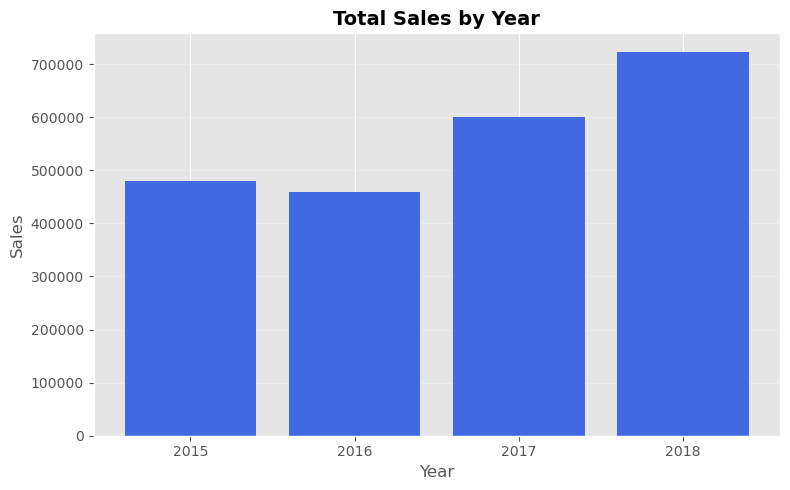

In [153]:
# Calculate yearly sales

yearly_sales = (
    sales_df
    .groupby("Year")["Sales"]
    .sum()
)

# Plot yearly sales

plt.figure(figsize=(8,5))

plt.bar(
    yearly_sales.index.astype(str),
    yearly_sales.values,
    color="royalblue"
)

plt.title(
    "Total Sales by Year",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Year")

plt.ylabel("Sales")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

plt.show()

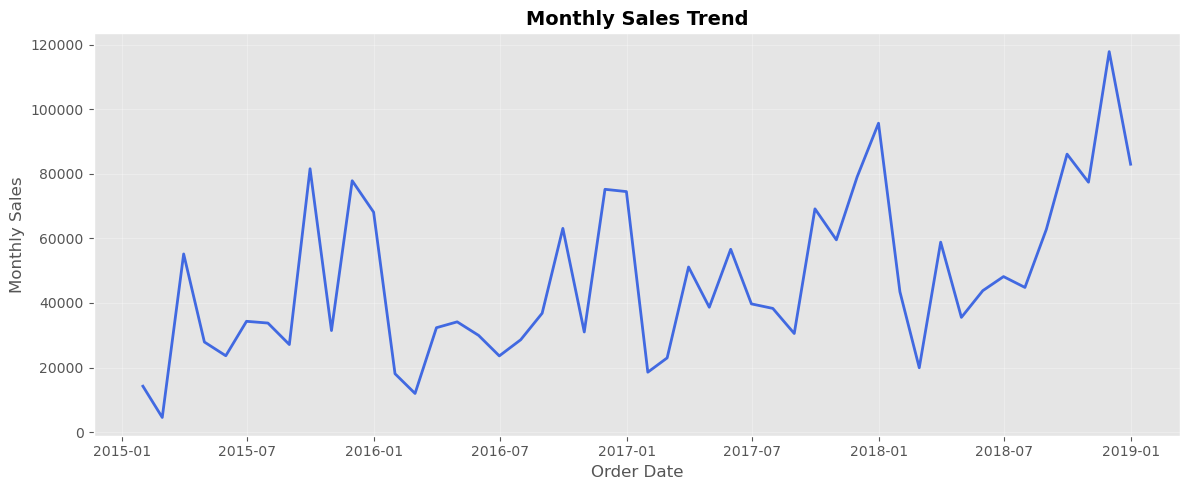

In [154]:
# Plot monthly sales trend

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    linewidth=2,
    color="royalblue"
)

plt.title(
    "Monthly Sales Trend",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Order Date")

plt.ylabel("Monthly Sales")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [134]:
# Display forecasting model comparison

comparison_table

,Model,MAE,RMSE,MAPE
0,SARIMA,19244.485343,19950.070419,20.526432
1,Prophet,20250.794413,22318.411333,21.864628
2,XGBoost,13915.321042,18893.847269,13.285401


In [135]:
# Display future sales forecast

future_forecast

,Forecast Month,Predicted Sales
0,2019-01-31,84327.281250
1,2019-02-28,51037.703125
2,2019-03-31,30091.779297


In [136]:
# Display anomalies detected using Isolation Forest

isolation_results

,Order Date,Sales,Isolation Forest
0,2015-01-04,304.508,1
5,2015-02-08,968.534,1
7,2015-02-22,224.912,1
11,2015-03-22,37703.665,1
28,2015-07-19,1387.686,1
36,2015-09-13,29959.137,1
55,2016-01-24,358.522,1
154,2017-12-17,25449.800,1
200,2018-11-04,29017.467,1
202,2018-11-18,30572.447,1


In [137]:
# Display anomalies detected using Z-Score

zscore_results

,Order Date,Sales,Isolation Forest,Rolling Mean,Rolling Std,Z Score,Z Anomaly
11,2015-03-22,37703.665,1,6832.006500,12546.138409,2.460650,True
29,2015-07-26,21590.080,0,8245.428325,6246.129535,2.136467,True
86,2016-08-28,15773.478,0,7515.302525,4020.682890,2.053924,True
89,2016-09-18,24095.960,0,10251.475400,6524.009519,2.122082,True
125,2017-05-28,23367.662,0,10265.959125,6524.022836,2.008225,True
168,2018-03-25,26029.904,0,8660.308925,7131.467537,2.435627,True


In [138]:
# Display clustered product demand segments

cluster_features

,Total Sales,Average Order Value,Sales Volatility,Growth Rate,Cluster,Demand Segment,PCA1,PCA2
Sub-Category,,,,,,,,
Accessories,164186.7000,217.178175,2579.994809,0.376381,2,High Volume Products,0.032855,-0.128039
Appliances,104618.4030,227.926804,1821.621539,0.399276,1,Steady Growth Products,-0.562213,0.137443
Art,26705.4100,34.019631,330.488343,0.166056,1,Steady Growth Products,-1.728503,-0.152657
Binders,200028.7850,134.067550,3848.223648,0.218736,2,High Volume Products,0.617483,-0.594676
Bookcases,113813.1987,503.598224,2220.405080,0.238065,1,Steady Growth Products,-0.119791,-0.064887
Chairs,322822.7310,531.833165,4407.232960,0.071358,2,High Volume Products,1.847288,-1.142316
Copiers,146248.0940,2215.880212,5500.774391,0.846718,0,Premium High-Value Products,2.868650,1.966394
Envelopes,16128.0460,65.032444,228.218688,-0.027666,1,Steady Growth Products,-1.804686,-0.479931
Fasteners,3001.9600,14.027850,48.742229,0.157034,1,Steady Growth Products,-1.980768,-0.094968


# Task 7 Summary

An interactive Streamlit dashboard was successfully developed for the Sales Forecasting and Demand Intelligence System.

The dashboard includes:

- Sales Overview Dashboard
- Forecast Explorer
- Anomaly Report
- Product Demand Segmentation
- Interactive filters for Region and Category
- KPI Cards
- Downloadable reports

The application enables users to explore historical sales, forecast future demand, identify anomalies, and analyze product demand segments through an interactive interface.
